### **Introduction**

This project required the integration of diverse datasets to facilitate a meaningful comparison between Bitcoin and Ethereum from both financial and environmental standpoints. To achieve this, we adopted an analytics-driven approach to data sourcing, cleaning, and auditing, using Python to ensure reproducibility, precision, and scalability.

Our analysis goes beyond numbers to examine how investors react, how confidence shifts, and whether the market rewards sustainability.Because the future of crypto won’t be decided by algorithms alone, it will be shaped by investor values, market resilience, and data-backed accountability.

Our analysis is guided by three key questions aimed at understanding their comparative performance:

1. Between 2020–2024, which asset Bitcoin or Ethereum has demonstrated stronger liquidity and price stability, and how do these trends correlate with their market capitalization changes?

2.Has Ethereum’s transition from Proof of Work (PoW) to Proof of Stake (PoS) in 2022 resulted in a tangible reduction in its network difficulty and energy consumption, relative to Bitcoin over the same period? 

3.During periods of extreme market stress (2022 crypto crash), which asset, Bitcoin or Ethereum, exhibited stronger investor confidence based on sustained trading volume and recovery patterns?






About the dataset:

| Dataset                                | Source          | Format & Size                  | Structure                                         | Audit Notes                                                                 |
|----------------------------------------|------------------|--------------------------------|--------------------------------------------------|------------------------------------------------------------------------------|
| 1. Bitcoin Historical Price Data (2021–2025) | [Investing.com](https://www.investing.com/crypto/bitcoin/historical-data)     | CSV; 1,416 rows × 7 columns     | Daily Open, Close, High, Low, Volume, % Change   | No missing/duplicate values. Date converted to YYYY-MM-DD. Volume cleaned. |
| 2. Bitcoin Kaggle Historical Data (2013–2021) | [Kaggle – Rajkumar](https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory)| CSV; 2,991 rows × 10 columns    | Daily Open, High, Low, Close, Volume, Market Cap | Clean. Timestamp truncated. Volume anomalies reviewed.                      |
| 3. Bitcoin Market Capitalization (2013–2025)  | [CoinGecko](https://www.coingecko.com/en/coins/bitcoin)         | CSV; 4,405 rows × 4 columns     | Price, Market Cap, Total Volume, snapped_at date | One missing value in market_cap. Dates aligned.                             |
| 4. Bitcoin Difficulty Index                  | [gigasheet.com](https://gigasheet.com/sample-data/bitcoin-blockchain-historical-data)    | CSV; 800,214 rows × 13 columns | height, timestamp, size, tx_count, difficulty, median_fee_rate, avg_fee_rate, total_fees, fee_range_min, fee_range_max, input_count, output_count, output_amount | Needs daily aggregation. No missing/duplicate entries.                    |
| 5. Bitcoin Energy Consumption                | [Digiconomist](https://digiconomist.net/bitcoin-energy-consumption)     | CSV; 3,021 rows × 3 columns     | DateTime, Estimated & Min TWh/year               | 365 missing in Estimated. Duplicate dates removed.                          |


| Dataset                                | Source          | Format & Size                  | Structure                                         | Audit Notes                                                                 |
|----------------------------------------|------------------|--------------------------------|--------------------------------------------------|------------------------------------------------------------------------------|
| 1. Ethereum Historical Price Data (2021–2025) | [Investing.com](https://www.investing.com/crypto/ethereum/historical-data)     | CSV; 1,416 rows × 7 columns     | Daily Open, Close, High, Low, Volume, % Change   | No missing/duplicate values. Date converted. Volume transformed from shorthand. |
| 2. Ethereum Kaggle Historical Data (2013–2021) | [Kaggle – Rajkumar](https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory) | CSV; 2,160 rows × 10 columns    | Daily Open, High, Low, Close, Volume, Market Cap | Clean. Timestamp truncated. Volume validated.                               |
| 3. Ethereum Market Capitalization (2013–2025)  | [CoinGecko](https://www.coingecko.com/en/coins/ethereum)         | CSV; 3,575 rows × 4 columns     | Price, Market Cap, Total Volume, snapped_at date | One missing market_cap. Date reformatted.                                   |
| 4. Ethereum Difficulty Index                  | [Etherscan.io](https://etherscan.io/chart/difficulty)      | CSV; 3,589 rows × 3 columns     | Date(UTC), Unix Timestamp, Value (difficulty)    | Daily entries. No missing/duplicate values. Date parsed.                    |
| 5. Ethereum Energy Consumption                | [Digiconomist](https://digiconomist.net/ethereum-energy-consumption)      | CSV; 2,918 rows × 3 columns     | DateTime, Estimated and Min TWh/year                       | 16 missing in minimum column. Dates aligned. No duplicates.                 |


### **Step 1: Import Libraries**

In [1]:
# Import standard libraries for data handling, analysis, and visualization
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import ttest_ind

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modeling libraries
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report

#Webscrapping
import requests


### **Step 2: Load CSV Files**


In [2]:
# Step 2.1: Load Bitcoin Files
df_bitcoin_2       = pd.read_csv("coin_Bitcoin.csv")
df_bitcoin_1       = pd.read_csv("Bitcoin Historical Data.csv")
df_bit_market_cap  = pd.read_csv("btc-usd-max.csv")
df_bit_energy      = pd.read_csv("bitcoin-energy-consumpti.csv")
df_bitcoin_difficulty = pd.read_csv("Bitcoin_Difficulty.csv")


# Step 2.2: Load Ethereum Files
df_ethereum_1          = pd.read_csv("Ethereum Historical Data.csv")
df_ethereum_2          = pd.read_csv("coin_Ethereum.csv")
df_ethereum_market_cap = pd.read_csv("eth-usd-max.csv")
df_ethereum_energy     = pd.read_csv("ethereum-energy-consumpt.csv")
df_ethereum_difficulty = pd.read_csv("Ethereum_Difficulty.csv")


#### **Step 2.1: Data Expolaration**


In [3]:
# Function to explore a dataset with detailed diagnostics
def explore_dataset(df, name):
    print(f"\n Dataset: {name}")
    print("-" * 60)
    
    # Display basic shape of the dataset (rows, columns)
    print("Shape (Rows, Columns):", df.shape)
    
    # List all column names
    print("Column Names:", df.columns.tolist())
    
    # Show data types of each column
    print("Data Types:")
    print(df.dtypes)
    
    # Show total number of missing values in each column
    print("Missing Values:")
    print(df.isnull().sum())
    
    # Display a few rows from the top to preview the data
    print("First 5 Rows:")
    print(df.head(5))
    
     # Display a few rows from the top to preview the data
    print("Last 5 Rows:")
    print(df.tail(5))

    # Show descriptive statistics for both numeric and object types
    print("Statistical Summary:")
    print(df.describe(include='all'))


##### Step 2.1.1: BitCoin Data Expolaration

In [4]:

# Bitcoin historical OHLC data (e.g., Date, Open, High, Low, Close, Volume)
explore_dataset(df_bitcoin_1, "Bitcoin Historical Data")



 Dataset: Bitcoin Historical Data
------------------------------------------------------------
Shape (Rows, Columns): (1416, 7)
Column Names: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
Data Types:
Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object
Missing Values:
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64
First 5 Rows:
         Date      Price       Open       High        Low     Vol. Change %
0  05/22/2025  109,964.3  109,632.6  110,095.3  109,539.7  121.49K    0.30%
1  05/21/2025  109,640.1  106,814.7  110,628.8  106,109.5  124.17K    2.64%
2  05/20/2025  106,815.8  105,586.1  107,270.5  104,199.3   76.08K    1.16%
3  05/19/2025  105,585.8  106,507.7  107,081.3  102,088.2   90.49K   -0.86%
4  05/18/2025  106,504.5  103,113.9  106,577.0  103,113.9   62.47K    3.29%
Last 5 Rows:
            Date     Price 

In [5]:

# Bitcoin daily prices and volumes (usually includes Marketcap, Volume, Close, etc.)
explore_dataset(df_bitcoin_2, "coin_Bitcoin")



 Dataset: coin_Bitcoin
------------------------------------------------------------
Shape (Rows, Columns): (2991, 10)
Column Names: ['SNo', 'Name', 'Symbol', 'Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Marketcap']
Data Types:
SNo            int64
Name          object
Symbol        object
Date          object
High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Marketcap    float64
dtype: object
Missing Values:
SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64
First 5 Rows:
   SNo     Name Symbol                 Date        High         Low  \
0    1  Bitcoin    BTC  2013-04-29 23:59:59  147.488007  134.000000   
1    2  Bitcoin    BTC  2013-04-30 23:59:59  146.929993  134.050003   
2    3  Bitcoin    BTC  2013-05-01 23:59:59  139.889999  107.720001   
3    4  Bitcoin    BTC  2013-05-02 23:59:59  125.599998   92.2818

In [6]:

# Bitcoin market cap from Yahoo/CoinGecko/Investing.com
explore_dataset(df_bit_market_cap, "Bitcoin Market Cap (btc-usd-max.csv)")



 Dataset: Bitcoin Market Cap (btc-usd-max.csv)
------------------------------------------------------------
Shape (Rows, Columns): (4405, 4)
Column Names: ['snapped_at', 'price', 'market_cap', 'total_volume']
Data Types:
snapped_at       object
price           float64
market_cap      float64
total_volume    float64
dtype: object
Missing Values:
snapped_at      0
price           0
market_cap      1
total_volume    0
dtype: int64
First 5 Rows:
                snapped_at   price    market_cap  total_volume
0  2013-04-28 00:00:00 UTC  135.30  1.500518e+09           0.0
1  2013-04-29 00:00:00 UTC  141.96  1.575032e+09           0.0
2  2013-04-30 00:00:00 UTC  135.30  1.501657e+09           0.0
3  2013-05-01 00:00:00 UTC  117.00  1.298952e+09           0.0
4  2013-05-02 00:00:00 UTC  103.43  1.148668e+09           0.0
Last 5 Rows:
                   snapped_at          price    market_cap  total_volume
4400  2025-05-17 00:00:00 UTC  103556.034940  2.057726e+12  2.588795e+10
4401  2025-05-18

In [7]:

# Bitcoin energy consumption over time (from Digiconomist or Cambridge)
explore_dataset(df_bit_energy, "Bitcoin Energy Consumption")



 Dataset: Bitcoin Energy Consumption
------------------------------------------------------------
Shape (Rows, Columns): (3021, 3)
Column Names: ['DateTime', 'Estimated TWh per Year', 'Minimum TWh per Year']
Data Types:
DateTime                   object
Estimated TWh per Year    float64
Minimum TWh per Year      float64
dtype: object
Missing Values:
DateTime                    0
Estimated TWh per Year    365
Minimum TWh per Year        0
dtype: int64
First 5 Rows:
              DateTime  Estimated TWh per Year  Minimum TWh per Year
0  2017-02-10 00:00:00                9.585659              3.331026
1  2017-02-11 00:00:00                9.547335              3.316227
2  2017-02-12 00:00:00                9.578774              3.198969
3  2017-02-13 00:00:00                9.476506              3.045178
4  2017-02-14 00:00:00                9.544807              3.150062
Last 5 Rows:
                 DateTime  Estimated TWh per Year  Minimum TWh per Year
3016  2025-05-16 00:00:00      

In [8]:

# Bitcoin mining difficulty dataset (hashrate difficulty over time)
explore_dataset(df_bitcoin_difficulty, "Bitcoin Difficulty")



 Dataset: Bitcoin Difficulty
------------------------------------------------------------
Shape (Rows, Columns): (800214, 13)
Column Names: ['height', 'timestamp', 'size', 'tx_count', 'difficulty', 'median_fee_rate', 'avg_fee_rate', 'total_fees', 'fee_range_min', 'fee_range_max', 'input_count', 'output_count', 'output_amount']
Data Types:
height               int64
timestamp            int64
size                 int64
tx_count             int64
difficulty         float64
median_fee_rate      int64
avg_fee_rate         int64
total_fees           int64
fee_range_min      float64
fee_range_max      float64
input_count          int64
output_count         int64
output_amount        int64
dtype: object
Missing Values:
height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtyp

##### Step 2.1.2: Ethereum Data Expolaration

In [9]:

# Ethereum historical OHLC data
explore_dataset(df_ethereum_1, "Ethereum Historical Data")



 Dataset: Ethereum Historical Data
------------------------------------------------------------
Shape (Rows, Columns): (1416, 7)
Column Names: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
Data Types:
Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object
Missing Values:
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64
First 5 Rows:
         Date     Price      Open      High       Low     Vol. Change %
0  05/22/2025  2,640.56  2,545.88  2,644.00  2,545.70    1.34M    3.49%
1  05/21/2025  2,551.42  2,523.42  2,614.54  2,454.72    1.21M    1.09%
2  05/20/2025  2,523.82  2,528.23  2,587.21  2,446.16  751.55K   -0.17%
3  05/19/2025  2,528.21  2,498.79  2,543.42  2,352.64  961.23K    1.17%
4  05/18/2025  2,498.97  2,475.04  2,585.12  2,340.94  905.26K    0.97%
Last 5 Rows:
            Date     Price      Open      High    

In [10]:

# Ethereum daily metrics from coin_Ethereum.csv (Close, Volume, Marketcap, etc.)
explore_dataset(df_ethereum_2, "coin_Ethereum")



 Dataset: coin_Ethereum
------------------------------------------------------------
Shape (Rows, Columns): (2160, 10)
Column Names: ['SNo', 'Name', 'Symbol', 'Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Marketcap']
Data Types:
SNo            int64
Name          object
Symbol        object
Date          object
High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Marketcap    float64
dtype: object
Missing Values:
SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64
First 5 Rows:
   SNo      Name Symbol                 Date      High       Low      Open  \
0    1  Ethereum    ETH  2015-08-08 23:59:59  2.798810  0.714725  2.793760   
1    2  Ethereum    ETH  2015-08-09 23:59:59  0.879810  0.629191  0.706136   
2    3  Ethereum    ETH  2015-08-10 23:59:59  0.729854  0.636546  0.713989   
3    4  Ethereum    ETH  2015-08-11 

In [11]:

# Ethereum market cap dataset
explore_dataset(df_ethereum_market_cap, "Ethereum Market Cap (eth-usd-max.csv)")



 Dataset: Ethereum Market Cap (eth-usd-max.csv)
------------------------------------------------------------
Shape (Rows, Columns): (3575, 4)
Column Names: ['snapped_at', 'price', 'market_cap', 'total_volume']
Data Types:
snapped_at       object
price           float64
market_cap      float64
total_volume    float64
dtype: object
Missing Values:
snapped_at      0
price           0
market_cap      1
total_volume    0
dtype: int64
First 5 Rows:
                snapped_at     price    market_cap  total_volume
0  2015-08-07 00:00:00 UTC  2.831620  0.000000e+00  9.062200e+04
1  2015-08-08 00:00:00 UTC  1.330750  8.033948e+07  3.680700e+05
2  2015-08-10 00:00:00 UTC  0.687586  4.155631e+07  4.004641e+05
3  2015-08-11 00:00:00 UTC  1.067379  6.453901e+07  1.518998e+06
4  2015-08-12 00:00:00 UTC  1.256613  7.601326e+07  2.073893e+06
Last 5 Rows:
                   snapped_at        price    market_cap  total_volume
3570  2025-05-17 00:00:00 UTC  2544.387038  3.076197e+11  2.113044e+10
3571  2

In [12]:

# Ethereum energy consumption data
explore_dataset(df_ethereum_energy, "Ethereum Energy Consumption")



 Dataset: Ethereum Energy Consumption
------------------------------------------------------------
Shape (Rows, Columns): (2918, 3)
Column Names: ['DateTime', 'Estimated TWh per Year', 'Minimum TWh per Year']
Data Types:
DateTime                   object
Estimated TWh per Year    float64
Minimum TWh per Year      float64
dtype: object
Missing Values:
DateTime                   0
Estimated TWh per Year     0
Minimum TWh per Year      16
dtype: int64
First 5 Rows:
              DateTime  Estimated TWh per Year  Minimum TWh per Year
0  2017-05-20 00:00:00                7.751334              2.131205
1  2017-05-21 00:00:00                8.480167              2.229735
2  2017-05-22 00:00:00                8.850687              2.275484
3  2017-05-23 00:00:00                9.275082              2.227113
4  2017-05-24 00:00:00                9.823090              2.259307
Last 5 Rows:
                 DateTime  Estimated TWh per Year  Minimum TWh per Year
2913  2025-05-16 00:00:00        

In [13]:

# Ethereum difficulty dataset (important for PoW vs PoS comparison)
explore_dataset(df_ethereum_difficulty, "Ethereum Difficulty")



 Dataset: Ethereum Difficulty
------------------------------------------------------------
Shape (Rows, Columns): (3585, 3)
Column Names: ['Date(UTC)', 'UnixTimeStamp', 'Value']
Data Types:
Date(UTC)         object
UnixTimeStamp      int64
Value            float64
dtype: object
Missing Values:
Date(UTC)        0
UnixTimeStamp    0
Value            0
dtype: int64
First 5 Rows:
   Date(UTC)  UnixTimeStamp  Value
0  7/30/2015     1438214400  0.121
1  7/31/2015     1438300800  0.603
2   8/1/2015     1438387200  0.887
3   8/2/2015     1438473600  1.020
4   8/3/2015     1438560000  1.126
Last 5 Rows:
      Date(UTC)  UnixTimeStamp  Value
3580  5/18/2025     1747526400    0.0
3581  5/19/2025     1747612800    0.0
3582  5/20/2025     1747699200    0.0
3583  5/21/2025     1747785600    0.0
3584  5/22/2025     1747872000    0.0
Statistical Summary:
        Date(UTC)  UnixTimeStamp         Value
count        3585   3.585000e+03   3585.000000
unique       3585            NaN           NaN
top    

### **Step 3: Data cleaning**

In [14]:
#  Universal data cleaning function to apply across crypto datasets

def clean_crypto_data(df, 
                      drop_cols=None, 
                      date_col="Date", 
                      vol_col="Volume", 
                      vol_alt_col="Vol.", 
                      numeric_cols=None,
                      filter_year_range=(2020, 2024)):
    """
    Cleans a crypto DataFrame:
    - Drops specified columns
    - Standardizes date format
    - Cleans volume columns
    - Cleans other numeric columns (e.g., High, Low, Close)
    - Optionally filters rows by year range

    Parameters:
        df (pd.DataFrame): The input DataFrame
        drop_cols (list): Columns to drop
        date_col (str): Column name for dates
        vol_col (str): Volume column name (default 'Volume')
        vol_alt_col (str): Alternate volume column name (e.g., 'Vol.')
        numeric_cols (list): Other numeric columns to clean (e.g., ['High', 'Low', 'Close'])
        filter_year_range (tuple): Year range (start_year, end_year) to filter on Date

    Returns:
        pd.DataFrame: Cleaned and filtered DataFrame
    """
    df = df.copy()

    # Drop unwanted columns
    if drop_cols:
        df = df.drop(columns=drop_cols, errors='ignore')

    # Convert and standardize date column
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce') \
                    .dt.tz_localize(None) \
                    .dt.strftime('%Y-%m-%d')
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Clean volume columns
    for col in [vol_col, vol_alt_col]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(",", "") \
                        .str.replace("[^0-9.]", "", regex=True) \
                        .replace("NA", np.nan)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Clean numeric columns (e.g., High, Low, Open, Close)
    if numeric_cols:
        for col in numeric_cols:
            if col in df.columns:
                df[col] = df[col].astype(str).str.replace(",", "").replace("NA", np.nan)
                df[col] = pd.to_numeric(df[col], errors='coerce')

    # Filter by year range
    if filter_year_range:
        start_year, end_year = filter_year_range
        df = df[
            (df[date_col].dt.year >= start_year) &
            (df[date_col].dt.year <= end_year)
        ]

    return df



#### Step 3.1: Bitcoin Dataset Cleaning and Integration

##### 3.1.1 - Cleaned version of  Bitcoin Dataset 'coin_Bitcoin' (Kaggle) 

In [15]:

# 3.1.1 - Clean coin_Bitcoin (Kaggle) by dropping unused columns and standardizing dates/volume
df_bitcoin_2_clean = clean_crypto_data(df_bitcoin_2, drop_cols=["SNo", "Name"])
df_bitcoin_2_clean


,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
2438,BTC,2020-01-01,7254.330611,7174.944153,7194.891971,7200.174393,1.856566e+10,1.305808e+11
2439,BTC,2020-01-02,7212.155253,6935.269972,7202.551122,6985.470001,2.080208e+10,1.266994e+11
2440,BTC,2020-01-03,7413.715099,6914.995908,6984.428612,7344.884183,2.811148e+10,1.332334e+11
2441,BTC,2020-01-04,7427.385794,7309.514012,7345.375275,7410.656566,1.844427e+10,1.344425e+11
2442,BTC,2020-01-05,7544.496872,7400.535561,7410.451694,7411.317327,1.972507e+10,1.344695e+11
...,...,...,...,...,...,...,...,...
2986,BTC,2021-07-02,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,BTC,2021-07-03,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,BTC,2021-07-04,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,BTC,2021-07-05,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11


##### 3.1.2 - Clean Bitcoin Historical Data (Investing.com)

In [16]:

# 3.1.2 - Clean Bitcoin Historical Data (Investing.com): standardize 'Date'
df_bitcoin_1["Date"] = pd.to_datetime(df_bitcoin_1["Date"], errors='coerce') \
                        .dt.tz_localize(None).dt.strftime('%Y-%m-%d')

df_bitcoin_1.rename(columns={"Price": "Close"}, inplace=True)

btc_numeric_cols = ["High", "Low", "Open", "Close", "Volume"]

df_bitcoin_1_clean = clean_crypto_data(df_bitcoin_1,numeric_cols=btc_numeric_cols)

# Convert % columns to float
df_bitcoin_1_clean['Change %'] = pd.to_numeric(df_bitcoin_1_clean['Change %'].str.rstrip('%'), errors='coerce')

df_bitcoin_1_clean.head(5)
explore_dataset(df_bitcoin_1_clean, "df_bitcoin_1_clean")


 Dataset: df_bitcoin_1_clean
------------------------------------------------------------
Shape (Rows, Columns): (1274, 7)
Column Names: ['Date', 'Close', 'Open', 'High', 'Low', 'Vol.', 'Change %']
Data Types:
Date        datetime64[ns]
Close              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object
Missing Values:
Date        0
Close       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64
First 5 Rows:
          Date    Close     Open     High      Low    Vol.  Change %
142 2024-12-31  93557.2  92777.2  96163.4  92036.2   74.85      0.84
143 2024-12-30  92779.8  93718.7  94936.4  91522.3  112.43     -1.00
144 2024-12-29  93716.3  95282.6  95315.4  93026.7   47.71     -1.65
145 2024-12-28  95284.5  94274.9  95684.3  94124.7   32.97      1.07
146 2024-12-27  94275.9  95776.4  97243.3  93472.8   85.12     -1.57
Last 5 Rows:
           Date   

##### 3.1.3 - Clean CoinGecko Market Cap data for Bitcoin


In [17]:
# 3.1.3 - Clean CoinGecko Market Cap data: format date, rename columns, convert to numeric

# Step 1: Rename and subset relevant columns
df_bit_market_cap_clean = df_bit_market_cap[["snapped_at", "market_cap", "total_volume"]].rename(columns={
    "snapped_at": "Date",
    "market_cap": "Marketcap",
    "total_volume": "Volume"
})

# Step 2: Clean using the universal function (convert Marketcap and Volume to numeric)
df_bit_market_cap_clean = clean_crypto_data(
    df_bit_market_cap_clean,
    numeric_cols=["Marketcap", "Volume"]
)

# Step 3: Set display format to avoid scientific notation
pd.set_option('display.float_format', '{:,.2f}'.format)

# Step 3: Preview cleaned dataset
df_bit_market_cap_clean.head(5)


,Date,Marketcap,Volume
2437,2020-01-01,"130,394,101,535.61","21,187,883,711.18"
2438,2020-01-02,"130,422,953,817.67","18,123,516,838.90"
2439,2020-01-03,"126,280,790,200.20","20,313,194,628.09"
2440,2020-01-04,"132,766,262,579.09","31,015,776,262.22"
2441,2020-01-05,"133,474,716,218.18","20,611,640,058.34"


##### 3.1.4 - Clean Energy Consumption Data for Bitcoin


In [18]:

# 3.1.4 - Clean Energy Consumption Data: parse date from first column
df_bit_energy["Date"] = pd.to_datetime(df_bit_energy.iloc[:, 0], errors='coerce') \
                          .dt.tz_localize(None).dt.strftime('%Y-%m-%d')

df_bit_energy = clean_crypto_data(
    df_bit_energy,
    drop_cols="DateTime",        # We already dropped manually         
    filter_year_range=None       # Keep all years
) 
df_bit_energy.head(5)


,Estimated TWh per Year,Minimum TWh per Year,Date
0,9.59,3.33,2017-02-10
1,9.55,3.32,2017-02-11
2,9.58,3.20,2017-02-12
3,9.48,3.05,2017-02-13
4,9.54,3.15,2017-02-14


##### 3.1.5 - Clean Difficulty Index Data for Bitcoin


In [19]:
# 3.1.5 - Clean Difficulty Data: convert timestamp, extract date, and aggregate

# Convert 'timestamp' from milliseconds to UTC datetime, then to string (temporarily used for column reordering)
df_bitcoin_difficulty['iso_datetime'] = pd.to_datetime(df_bitcoin_difficulty['timestamp'], unit='ms', utc=True).astype(str)

# Reorder columns to place 'iso_datetime' at the front
df_bitcoin_difficulty = df_bitcoin_difficulty[['iso_datetime'] + [col for col in df_bitcoin_difficulty.columns if col != 'iso_datetime']]

# Convert 'iso_datetime' back from string to datetime object for further processing
df_bitcoin_difficulty['iso_datetime'] = pd.to_datetime(df_bitcoin_difficulty['iso_datetime'])

# Extract only the date part (YYYY-MM-DD) from 'iso_datetime' into a new column
df_bitcoin_difficulty['date_only'] = df_bitcoin_difficulty['iso_datetime'].dt.date

# Group the data by date and calculate the average difficulty for each day
df_bitcoin_difficulty = df_bitcoin_difficulty.groupby('date_only')['difficulty'].mean().reset_index()

# Rename columns to 'Date' and 'Average_Difficulty (TH)' for clarity
df_bitcoin_difficulty.columns = ['Date', 'Average_Difficulty (TH)']

# Convert 'Date' column to datetime format to enable accurate merging with other datasets
df_bitcoin_difficulty['Date'] = pd.to_datetime(df_bitcoin_difficulty['Date'])


df_bitcoin_difficulty.tail(5)

,Date,Average_Difficulty (TH)
5306,2023-07-21,"53,911,173,001,054.59"
5307,2023-07-22,"53,911,173,001,054.59"
5308,2023-07-23,"53,911,173,001,054.59"
5309,2023-07-24,"53,911,173,001,054.59"
5310,2023-07-25,"53,911,173,001,054.59"


##### 3.1.6 - Merge Bitcoin Historical data

In [20]:

# 3.1.6 - Merge Bitcoin Historical data with Market Cap data on 'Date'
df_bit_combined = pd.merge(df_bitcoin_1_clean, df_bit_market_cap_clean, how="left", on="Date")

df_bit_combined.head(5)


,Date,Close,Open,High,Low,Vol.,Change %,Marketcap,Volume
0,2024-12-31,"93,557.20","92,777.20","96,163.40","92,036.20",74.85,0.84,"1,833,188,187,477.53","57,595,164,139.47"
1,2024-12-30,"92,779.80","93,718.70","94,936.40","91,522.30",112.43,-1.00,"1,854,872,605,738.81","24,065,314,499.50"
2,2024-12-29,"93,716.30","95,282.60","95,315.40","93,026.70",47.71,-1.65,"1,885,556,552,231.43","22,429,850,903.94"
3,2024-12-28,"95,284.50","94,274.90","95,684.30","94,124.70",32.97,1.07,"1,867,708,753,554.92","41,498,540,807.67"
4,2024-12-27,"94,275.90","95,776.40","97,243.30","93,472.80",85.12,-1.57,"1,894,744,251,986.11","45,049,342,388.19"


##### 3.1.7 - Merge cleaned Kaggle data

In [21]:

# 3.1.7 - Merge cleaned Kaggle data with the merged Investing+Marketcap data
df_bitcoin_final = pd.concat([df_bitcoin_2_clean, df_bit_combined], ignore_index=True)


##### 3.1.8 - Fill missing Close and Volume values

In [22]:

# 3.1.8 - Fill missing Close and Volume values using alternate columns
df_bitcoin_final["Close"] = df_bitcoin_final["Close"].combine_first(df_bitcoin_final.get("Close"))
df_bitcoin_final["Volume"] = df_bitcoin_final["Volume"].combine_first(df_bitcoin_final.get("Vol."))


##### 3.1.9 - Drop redundant columns

In [23]:

# 3.1.9 - Drop redundant columns (Price, Vol.)
df_bitcoin_final = clean_crypto_data(df_bitcoin_final, drop_cols=["Price", "Vol."])


##### 3.1.10 - Ensure Symbol column exist

In [24]:

# 3.1.10 - Ensure Symbol column exists; default to 'BTC'
df_bitcoin_final["Symbol"] = df_bitcoin_final.get("Symbol", "BTC").fillna("BTC")


##### 3.1.11 - Merge with Energy Consumption data

In [25]:

# 3.1.11 - Merge with Energy Consumption data

# Ensure both Date columns are in datetime64[ns] format
df_bitcoin_final["Date"] = pd.to_datetime(df_bitcoin_final["Date"], errors='coerce')
df_bit_energy["Date"] = pd.to_datetime(df_bit_energy["Date"], errors='coerce')

# Proceed with merge
df_bitcoin_final = pd.merge(df_bitcoin_final, df_bit_energy, how="left", on="Date")



##### 3.1.12 - Drop rows with missing essential values for analysis

In [26]:

# 3.1.12 - Drop rows with missing essential values for analysis
df_bitcoin_final_cleaned = df_bitcoin_final.dropna(subset=[
    "Date", "High", "Low", "Open", "Close", "Marketcap", 
    "Minimum TWh per Year"
])


##### 3.1.13 - Format Date and sort

In [27]:

# 3.1.13 - Format Date and sort chronologically
df_bitcoin_final_cleaned["Date"] = pd.to_datetime(df_bitcoin_final_cleaned["Date"])
df_bitcoin_final_cleaned = df_bitcoin_final_cleaned.sort_values(by="Date").reset_index(drop=True)


C:\Users\Raghu\AppData\Local\Temp\ipykernel_2660\1782534888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bitcoin_final_cleaned["Date"] = pd.to_datetime(df_bitcoin_final_cleaned["Date"])


##### 3.1.14 - Merge cleaned BTC data with difficulty data

In [28]:

# 3.1.14 - Merge cleaned BTC data with difficulty data
df_bitcoin_with_difficulty = pd.merge(
    df_bitcoin_final_cleaned,
    df_bitcoin_difficulty,
    on="Date",
    how="left"
)


##### 3.1.15 - Prefix all columns with 'Btc_'

In [29]:

# 3.1.15 - Prefix all columns with 'Btc_' for multi-coin alignment and rename Date back
df_bitcoin_with_difficulty.columns = ['Btc_' + col for col in df_bitcoin_with_difficulty.columns]
df_bitcoin_with_difficulty.rename(columns={'Btc_Date': 'Date'}, inplace=True)


##### 3.1.16 - Drop unnecessary columns

In [30]:

# 3.1.16 - Drop unnecessary columns like Symbol or DateTime if present
df_bitcoin_with_difficulty = clean_crypto_data(df_bitcoin_with_difficulty, drop_cols=["Btc_Symbol", "Btc_DateTime"])


##### 3.1.17 - Output summary of cleaned and merged Bitcoin data

In [31]:

# 3.1.17 - Output summary of cleaned and merged Bitcoin data
explore_dataset(df_bitcoin_with_difficulty, "Final Merged Bitcoin DataSet")



 Dataset: Final Merged Bitcoin DataSet
------------------------------------------------------------
Shape (Rows, Columns): (1828, 11)
Column Names: ['Date', 'Btc_High', 'Btc_Low', 'Btc_Open', 'Btc_Close', 'Btc_Volume', 'Btc_Marketcap', 'Btc_Change %', 'Btc_Estimated TWh per Year', 'Btc_Minimum TWh per Year', 'Btc_Average_Difficulty (TH)']
Data Types:
Date                           datetime64[ns]
Btc_High                              float64
Btc_Low                               float64
Btc_Open                              float64
Btc_Close                             float64
Btc_Volume                            float64
Btc_Marketcap                         float64
Btc_Change %                          float64
Btc_Estimated TWh per Year            float64
Btc_Minimum TWh per Year              float64
Btc_Average_Difficulty (TH)           float64
dtype: object
Missing Values:
Date                             0
Btc_High                         0
Btc_Low                          0
Btc_O

#### Step 3.2: Clean Ethereum dataset


##### 3.2.1 - Cleaned version of Ethereum data 'coin_Ethereum' (Kaggle) 

In [32]:

# 3.2.1 - Clean coin_Ethereum (Kaggle) using universal cleaner
df_ethereum_2_clean = clean_crypto_data(df_ethereum_2, drop_cols=["SNo", "Name"])

df_ethereum_2_clean


,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
1607,ETH,2020-01-01,132.84,129.20,129.63,130.80,"7,935,230,330.48","14,271,059,633.08"
1608,ETH,2020-01-02,130.82,126.95,130.82,127.41,"8,032,709,256.08","13,902,505,466.24"
1609,ETH,2020-01-03,134.55,126.49,127.41,134.17,"10,476,845,358.08","14,642,130,119.66"
1610,ETH,2020-01-04,136.05,133.04,134.17,135.07,"7,430,904,515.09","14,741,946,278.13"
1611,ETH,2020-01-05,139.41,135.05,135.07,136.28,"7,526,675,353.24","14,875,569,429.66"
...,...,...,...,...,...,...,...,...
2155,ETH,2021-07-02,"2,155.60","2,021.82","2,109.89","2,150.04","31,796,212,553.95","250,552,745,326.39"
2156,ETH,2021-07-03,"2,237.57","2,117.59","2,150.84","2,226.11","17,433,361,640.79","259,447,545,607.53"
2157,ETH,2021-07-04,"2,384.29","2,190.84","2,226.55","2,321.72","18,787,107,473.09","270,621,669,241.05"
2158,ETH,2021-07-05,"2,321.92","2,163.04","2,321.92","2,198.58","20,103,794,829.49","256,297,846,064.35"


##### 3.2.2 - Clean Ethereum Historical Data 

In [33]:

# 3.2.2 - Clean Ethereum Historical Data (Investing.com): standardize 'Date'
df_ethereum_1["Date"] = pd.to_datetime(df_ethereum_1["Date"], errors='coerce') \
                          .dt.tz_localize(None).dt.strftime('%Y-%m-%d')

df_ethereum_1.rename(columns={"Price": "Close"}, inplace=True)

eth_numeric_cols = ["High", "Low", "Open", "Close", "Volume"]

df_ethereum_1_clean = clean_crypto_data(df_ethereum_1,numeric_cols=eth_numeric_cols)

# Convert % columns to float
df_ethereum_1_clean['Change %'] = pd.to_numeric(df_ethereum_1_clean['Change %'].str.rstrip('%'), errors='coerce')

explore_dataset(df_ethereum_1_clean, "df_ethereum_1_clean")



 Dataset: df_ethereum_1_clean
------------------------------------------------------------
Shape (Rows, Columns): (1274, 7)
Column Names: ['Date', 'Close', 'Open', 'High', 'Low', 'Vol.', 'Change %']
Data Types:
Date        datetime64[ns]
Close              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object
Missing Values:
Date        0
Close       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64
First 5 Rows:
          Date    Close     Open     High      Low   Vol.  Change %
142 2024-12-31 3,337.80 3,361.99 3,449.27 3,317.39 333.44     -0.72
143 2024-12-30 3,361.99 3,355.97 3,436.83 3,306.11 494.99      0.18
144 2024-12-29 3,355.97 3,404.53 3,412.32 3,327.45 176.43     -1.43
145 2024-12-28 3,404.59 3,334.23 3,427.65 3,322.42 196.38      2.11
146 2024-12-27 3,334.19 3,335.96 3,438.85 3,309.03 378.00     -0.05
Last 5 Rows:
           Date    Clos

##### 3.2.3 - Clean Ethereum Market Cap Data

In [34]:

# 3.2.3 - Clean Ethereum Market Cap Data: standardize date, rename columns
df_ethereum_market_cap["Date"] = pd.to_datetime(df_ethereum_market_cap["snapped_at"], errors='coerce') \
                                   .dt.tz_localize(None).dt.strftime('%Y-%m-%d')
df_ethereum_market_cap_clean = df_ethereum_market_cap[["Date", "market_cap", "total_volume"]].rename(columns={
    "market_cap": "Marketcap",
    "total_volume": "Volume"
})

# Ensure 'Date' columns in both datasets are datetime64[ns]

df_ethereum_market_cap_clean['Date'] = pd.to_datetime(df_ethereum_market_cap_clean['Date'], errors='coerce')

explore_dataset(df_ethereum_market_cap_clean, "df_ethereum_market_cap_clean")



 Dataset: df_ethereum_market_cap_clean
------------------------------------------------------------
Shape (Rows, Columns): (3575, 3)
Column Names: ['Date', 'Marketcap', 'Volume']
Data Types:
Date         datetime64[ns]
Marketcap           float64
Volume              float64
dtype: object
Missing Values:
Date         0
Marketcap    1
Volume       0
dtype: int64
First 5 Rows:
        Date     Marketcap       Volume
0 2015-08-07          0.00    90,622.00
1 2015-08-08 80,339,475.00   368,070.00
2 2015-08-10 41,556,309.21   400,464.07
3 2015-08-11 64,539,006.31 1,518,998.21
4 2015-08-12 76,013,261.05 2,073,893.35
Last 5 Rows:
           Date          Marketcap            Volume
3570 2025-05-17 307,619,694,635.77 21,130,441,534.97
3571 2025-05-18 298,789,831,687.00 17,185,510,890.70
3572 2025-05-19 296,863,390,804.25 24,797,434,472.36
3573 2025-05-20 305,077,067,863.08 25,363,871,274.83
3574 2025-05-21 304,737,250,158.37 22,871,462,735.42
Statistical Summary:
                              

##### 3.2.4 - Merge Historical Price and Market Cap Data 

In [35]:

# 3.2.4 - Merge Historical Price and Market Cap Data on 'Date'
df_ethereum_combined = pd.merge(df_ethereum_1_clean, df_ethereum_market_cap_clean, how="left", on="Date")

explore_dataset(df_ethereum_combined, "df_ethereum_combined")



 Dataset: df_ethereum_combined
------------------------------------------------------------
Shape (Rows, Columns): (1274, 9)
Column Names: ['Date', 'Close', 'Open', 'High', 'Low', 'Vol.', 'Change %', 'Marketcap', 'Volume']
Data Types:
Date         datetime64[ns]
Close               float64
Open                float64
High                float64
Low                 float64
Vol.                float64
Change %            float64
Marketcap           float64
Volume              float64
dtype: object
Missing Values:
Date         0
Close        0
Open         0
High         0
Low          0
Vol.         0
Change %     0
Marketcap    0
Volume       0
dtype: int64
First 5 Rows:
        Date    Close     Open     High      Low   Vol.  Change %  \
0 2024-12-31 3,337.80 3,361.99 3,449.27 3,317.39 333.44     -0.72   
1 2024-12-30 3,361.99 3,355.97 3,436.83 3,306.11 494.99      0.18   
2 2024-12-29 3,355.97 3,404.53 3,412.32 3,327.45 176.43     -1.43   
3 2024-12-28 3,404.59 3,334.23 3,427.65 3,32

##### 3.2.5 - Concatenate cleaned coin_Ethereum with merged Investing+MarketCap

In [36]:

# 3.2.5 - Concatenate cleaned coin_Ethereum with merged Investing+MarketCap
df_ethereum_final = pd.concat([df_ethereum_2_clean, df_ethereum_combined], ignore_index=True)


##### 3.2.6 - Filling the missing Values

In [37]:

# 3.2.6 - Fill missing 'Close' and 'Volume' values using backup columns ('Price' and 'Vol.')


# Check and fill 'Close' from 'Price' if 'Price' column is available
if "Price" in df_ethereum_final.columns:
    df_ethereum_final["Close"] = df_ethereum_final["Close"].combine_first(df_ethereum_final["Price"])

# Check and fill 'Volume' from 'Vol.' if 'Vol.' column is available
if "Vol." in df_ethereum_final.columns:
    df_ethereum_final["Volume"] = df_ethereum_final["Volume"].combine_first(df_ethereum_final["Vol."])



##### 3.2.7 - Drop redundant columns

In [38]:

# 3.2.7 - Drop redundant columns using cleaner function
df_ethereum_final = clean_crypto_data(df_ethereum_final, drop_cols=["Price", "Vol."])


##### 3.2.8 - Assign value to  missing Symbol values

In [39]:

# 3.2.8 - Assign 'ETH' to missing Symbol values
df_ethereum_final["Symbol"] = df_ethereum_final.get("Symbol", "ETH").fillna("ETH")


##### 3.2.9 - Merge with Energy Consumption Data

In [40]:

# 3.2.9 - Merge with Energy Consumption Data
df_ethereum_energy["Date"] = pd.to_datetime(df_ethereum_energy.iloc[:, 0], errors='coerce') \
                                .dt.tz_localize(None).dt.strftime('%Y-%m-%d')
df_ethereum_final["Date"] = pd.to_datetime(df_ethereum_final["Date"], errors='coerce') \
                              .dt.strftime('%Y-%m-%d')
df_ethereum_final = pd.merge(df_ethereum_final, df_ethereum_energy, how="left", on="Date")



##### 3.2.10 - Dropped rows with missing values

In [41]:

# 3.2.10 - Drop rows missing key metrics needed for analysis
df_ethereum_final_cleaned = df_ethereum_final.dropna(subset=[
    "Date", "High", "Low", "Open", "Close", "Marketcap",
    "Minimum TWh per Year"
])


##### 3.2.11 - Format Date and sort chronologically

In [42]:

# 3.2.11 - Format Date and sort chronologically
df_ethereum_final_cleaned["Date"] = pd.to_datetime(df_ethereum_final_cleaned["Date"])
df_ethereum_final_cleaned = df_ethereum_final_cleaned.sort_values(by="Date").reset_index(drop=True)


C:\Users\Raghu\AppData\Local\Temp\ipykernel_2660\1483121167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ethereum_final_cleaned["Date"] = pd.to_datetime(df_ethereum_final_cleaned["Date"])


##### 3.2.12 - Cleaned Difficulty Index Dataset

In [43]:
# 3.2.12 - Clean Difficulty Dataset: drop,  and convert Date
df_ethereum_difficulty = df_ethereum_difficulty.drop(columns=['UnixTimeStamp'], errors='ignore')
df_ethereum_difficulty.columns = ['Date', 'Average_Difficulty (TH)']
df_ethereum_difficulty["Date"] = pd.to_datetime(df_ethereum_difficulty["Date"])


##### 3.2.13 - Merge Cleaned Ethereum Data with Difficulty Data

In [44]:

# 3.2.13 - Merge Cleaned Ethereum Data with Difficulty Data
df_ethereum_with_difficulty = pd.merge(
    df_ethereum_final_cleaned,
    df_ethereum_difficulty,
    on="Date",
    how="left"
)


##### 3.2.14 - Adding  prefix to all columns and restoring  column name

In [45]:

# 3.2.14 - Add 'Eth_' prefix to all columns and restore 'Date' column name
df_ethereum_with_difficulty.columns = ['Eth_' + col for col in df_ethereum_with_difficulty.columns]
df_ethereum_with_difficulty.rename(columns={'Eth_Date': 'Date'}, inplace=True)


##### 3.2.15 - Drop unnecessary columns 

In [46]:

# 3.2.15 - Drop unnecessary columns using cleaner function
df_ethereum_with_difficulty = clean_crypto_data(df_ethereum_with_difficulty, drop_cols=["Eth_Symbol", "Eth_DateTime"])


##### 3.2.16 -  Summary statistics

In [47]:

# 3.2.16 - Output summary statistics
explore_dataset(df_ethereum_with_difficulty, "Final Merged Ethereum DataSet")


 Dataset: Final Merged Ethereum DataSet
------------------------------------------------------------
Shape (Rows, Columns): (1810, 11)
Column Names: ['Date', 'Eth_High', 'Eth_Low', 'Eth_Open', 'Eth_Close', 'Eth_Volume', 'Eth_Marketcap', 'Eth_Change %', 'Eth_Estimated TWh per Year', 'Eth_Minimum TWh per Year', 'Eth_Average_Difficulty (TH)']
Data Types:
Date                           datetime64[ns]
Eth_High                              float64
Eth_Low                               float64
Eth_Open                              float64
Eth_Close                             float64
Eth_Volume                            float64
Eth_Marketcap                         float64
Eth_Change %                          float64
Eth_Estimated TWh per Year            float64
Eth_Minimum TWh per Year              float64
Eth_Average_Difficulty (TH)           float64
dtype: object
Missing Values:
Date                             0
Eth_High                         0
Eth_Low                          0
Eth_

### **Step 4. Combining both the dataset (bitcoin and ethereum)**

In [48]:
# This creates a unified dataset with BTC and ETH metrics aligned by date
merged_data = pd.merge(df_bitcoin_with_difficulty, df_ethereum_with_difficulty, on='Date', how='inner')
explore_dataset(merged_data, "merged_data")


 Dataset: merged_data
------------------------------------------------------------
Shape (Rows, Columns): (1812, 21)
Column Names: ['Date', 'Btc_High', 'Btc_Low', 'Btc_Open', 'Btc_Close', 'Btc_Volume', 'Btc_Marketcap', 'Btc_Change %', 'Btc_Estimated TWh per Year', 'Btc_Minimum TWh per Year', 'Btc_Average_Difficulty (TH)', 'Eth_High', 'Eth_Low', 'Eth_Open', 'Eth_Close', 'Eth_Volume', 'Eth_Marketcap', 'Eth_Change %', 'Eth_Estimated TWh per Year', 'Eth_Minimum TWh per Year', 'Eth_Average_Difficulty (TH)']
Data Types:
Date                           datetime64[ns]
Btc_High                              float64
Btc_Low                               float64
Btc_Open                              float64
Btc_Close                             float64
Btc_Volume                            float64
Btc_Marketcap                         float64
Btc_Change %                          float64
Btc_Estimated TWh per Year            float64
Btc_Minimum TWh per Year              float64
Btc_Average_Difficu

####  META DATA FOR merged_data
• Open: The price of the crypto at the start of the trading day.  

• Close: The price at the end of the trading day.  

• High: The highest price reached during the day.  

• Low: The lowest price reached during the day.  

• Volume: The total value of a cryptocurrency traded (bought or sold) within a specific time.  

• Market capitalization: The total value of a cryptocurrency in circulation.  

• Difficulty Index: The difficulty index measures how hard it is to mine a new Bitcoin block and automatically adjusts based on network activity to ensure consistent block times, requiring more computational effort as difficulty increases.  

• Energy Consumption: Represents the minimum amount of electrical energy consumed annually by the network to perform mining (for Bitcoin) or validation (for Ethereum post-Merge).TWh (Terawatt-hour) is a unit that shows how much electricity a system uses.  

### **Step 5. Filtering the merged dataset**


In [49]:

# Ensure the Date column is in datetime format
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

# Filter data between 2020 and 2024 (inclusive)
filtered_data = merged_data[(merged_data['Date'].dt.year >= 2020) & (merged_data['Date'].dt.year <= 2024)]
explore_dataset(filtered_data, "filtered_data")



 Dataset: filtered_data
------------------------------------------------------------
Shape (Rows, Columns): (1812, 21)
Column Names: ['Date', 'Btc_High', 'Btc_Low', 'Btc_Open', 'Btc_Close', 'Btc_Volume', 'Btc_Marketcap', 'Btc_Change %', 'Btc_Estimated TWh per Year', 'Btc_Minimum TWh per Year', 'Btc_Average_Difficulty (TH)', 'Eth_High', 'Eth_Low', 'Eth_Open', 'Eth_Close', 'Eth_Volume', 'Eth_Marketcap', 'Eth_Change %', 'Eth_Estimated TWh per Year', 'Eth_Minimum TWh per Year', 'Eth_Average_Difficulty (TH)']
Data Types:
Date                           datetime64[ns]
Btc_High                              float64
Btc_Low                               float64
Btc_Open                              float64
Btc_Close                             float64
Btc_Volume                            float64
Btc_Marketcap                         float64
Btc_Change %                          float64
Btc_Estimated TWh per Year            float64
Btc_Minimum TWh per Year              float64
Btc_Average_Diffi

Filtering data from 2020 to 2024 focuses the analysis on a critical period of volatility and transformation in crypto markets capturing Bitcoin’s institutional rise, Ethereum’s shift to Proof-of-Stake, and how both assets responded to macroeconomic shocks and recovery.(Luna Crash and FTX Collapse)


______________________________________________________________________________________________________________________________________________________________________

### **Step 6 Analysis**




#### 6.1 Question-1:  Between 2020–2024, which asset Bitcoin or Ethereum has demonstrated stronger liquidity and price stability, and how do these trends correlate with their market capitalization changes?


##### 6.1.1 Liquidity Ratio Calculation

In [50]:
# This calculates Bitcoin’s and Ethereum's  daily liquidity ratio by dividing its daily trading volume by its market capitalization.
# The result provides a measure of how easily Bitcoin can be traded relative to its market size.

filtered_data['btc_liquidity_ratio'] = filtered_data['Btc_Volume'] / filtered_data['Btc_Marketcap']

filtered_data['eth_liquidity_ratio'] = filtered_data['Eth_Volume'] / filtered_data['Eth_Marketcap']


##### 6.1.2 Liquidity ratio between Bitcoin and Ethereum

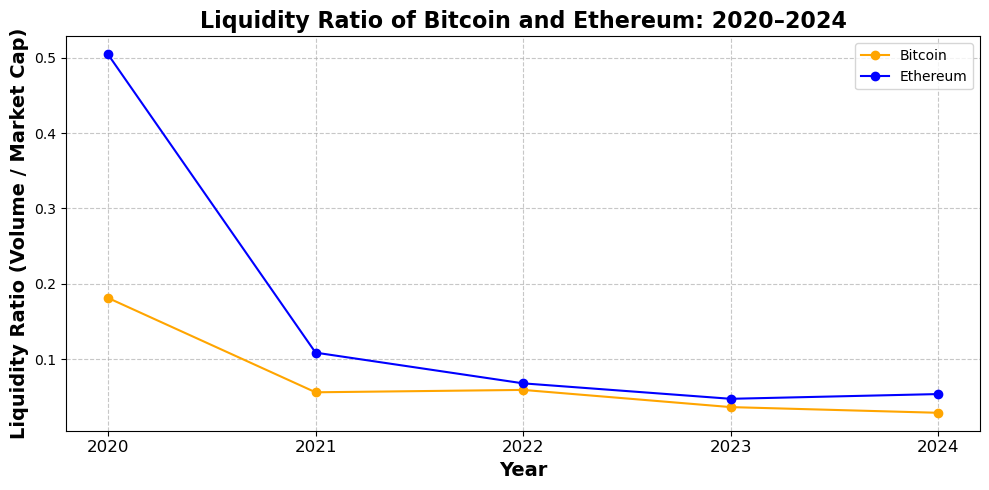

In [51]:
# This line extracts the year from the 'Date' column and stores it in a new column called 'Year'.
# It enables grouping and analysis at the yearly level.
filtered_data['Year'] = pd.to_datetime(filtered_data['Date']).dt.year

# This block computes the average liquidity ratio for both Bitcoin and Ethereum on a yearly basis.
# It groups the data by year and calculates the mean of daily liquidity ratios for each asset.
liquidity_ratio_yearly = (
    filtered_data.groupby('Year')
    .agg(
        btc_liquidity_ratio=('btc_liquidity_ratio', 'mean'),  # Annual average of Bitcoin liquidity ratio
        eth_liquidity_ratio=('eth_liquidity_ratio', 'mean')   # Annual average of Ethereum liquidity ratio
    )
    .reset_index()  # Convert the result into a clean DataFrame with Year as a column
)

# This block initializes the line plot to compare the yearly liquidity ratios of Bitcoin and Ethereum.
# It sets the figure size to 10 inches wide by 5 inches tall for optimal readability.
plt.figure(figsize=(10, 5))

# This line plots Bitcoin's average yearly liquidity ratio using orange markers.
# Each point represents the mean liquidity for a given year.
plt.plot(
    liquidity_ratio_yearly['Year'],
    liquidity_ratio_yearly['btc_liquidity_ratio'],
    marker='o',
    label='Bitcoin',
    color='orange'
)

# This line plots Ethereum's average yearly liquidity ratio using blue markers.
# The line facilitates visual comparison with Bitcoin across the same time frame.
plt.plot(
    liquidity_ratio_yearly['Year'],
    liquidity_ratio_yearly['eth_liquidity_ratio'],
    marker='o',
    label='Ethereum',
    color='blue'
)

# This block sets the chart’s main title and axis labels to describe the content clearly.
plt.title('Liquidity Ratio of Bitcoin and Ethereum: 2020–2024', fontsize=16, fontweight='bold')
plt.xlabel('Year',fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, )
plt.ylabel('Liquidity Ratio (Volume / Market Cap)',fontsize=14, fontweight='bold')

# This line ensures the x-axis displays each year label precisely.
plt.xticks(liquidity_ratio_yearly['Year'])

# This line adds a legend to distinguish between Bitcoin and Ethereum.
plt.legend()

# This block adds a light dashed grid to improve readability of data points.
plt.grid(True, linestyle='--', alpha=0.7)

# This call ensures all elements (labels, title, legend) are properly spaced.
plt.tight_layout()

# This command displays the completed line chart.
plt.show()



##### 6.1.3 Volatility Comparison (Standard Deviation of Daily % Change)

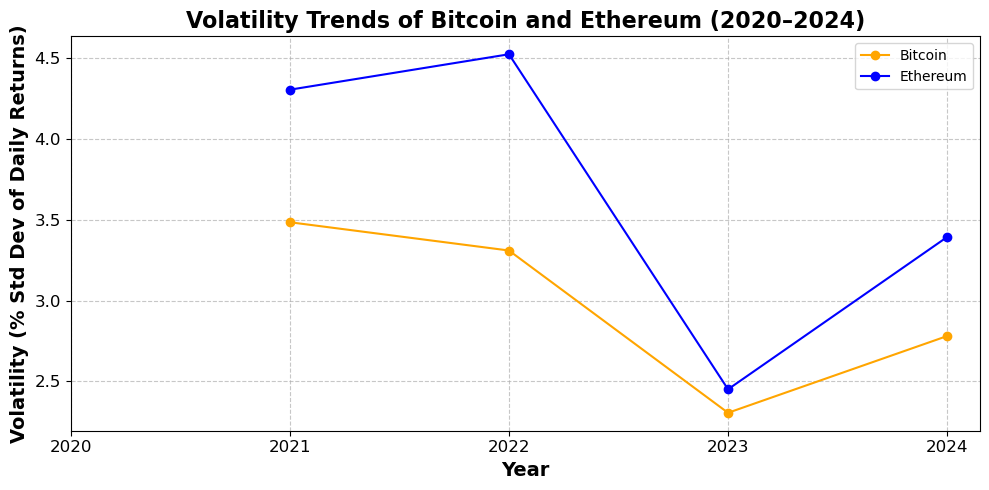

In [52]:
# This line extracts the year from each date and stores it in a new column called 'Year'.
# It prepares the data for annual-level grouping and aggregation.
filtered_data['Year'] = pd.to_datetime(filtered_data['Date']).dt.year

# This block calculates yearly price volatility for Bitcoin and Ethereum using the standard deviation of daily returns.
# It groups the data by year and computes the standard deviation of the 'Change %' column for each asset.
yearly_volatility = (
    filtered_data.groupby('Year')
    .agg(
        btc_volatility=('Btc_Change %', 'std'),  # Yearly standard deviation of Bitcoin daily returns
        eth_volatility=('Eth_Change %', 'std')   # Yearly standard deviation of Ethereum daily returns
    )
    .reset_index()  # Converts the grouped result into a tidy DataFrame
)


# This block initializes the line chart for visualizing yearly volatility of Bitcoin and Ethereum.
# It sets the figure size to 10 inches wide by 5 inches tall for clarity and readability.
plt.figure(figsize=(10, 5))

# This line plots Bitcoin’s annual volatility, measured as the standard deviation of daily returns.
# Orange markers indicate the volatility value for each year.
plt.plot(
    yearly_volatility['Year'],
    yearly_volatility['btc_volatility'],
    marker='o',
    label='Bitcoin',
    color='orange'
)

# This line plots Ethereum’s annual volatility using the same method.
# Blue markers help distinguish Ethereum from Bitcoin in the visualization.
plt.plot(
    yearly_volatility['Year'],
    yearly_volatility['eth_volatility'],
    marker='o',
    label='Ethereum',
    color='blue'
)

# This block sets the main title and axis labels to clearly describe the chart’s contents.
plt.title('Volatility Trends of Bitcoin and Ethereum (2020–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year',fontsize=14, fontweight='bold')
plt.ylabel('Volatility (% Std Dev of Daily Returns)',fontsize=14, fontweight='bold')

# This line ensures that each year is correctly labeled on the x-axis.
plt.xticks(yearly_volatility['Year'], fontsize=12)
plt.yticks(fontsize=12)

# This line adds a legend to differentiate between the two cryptocurrencies.
plt.legend()

# This line enables a light dashed grid to improve visual tracking across the chart.
plt.grid(True, linestyle='--', alpha=0.7)

# This call optimizes spacing to prevent overlapping of plot elements.
plt.tight_layout()

# This command renders and displays the completed line chart.
plt.show()



##### 6.1.4 Analyzing Bitcoin Volume and Market Value Trends Across Market Cycles (2020–2024)

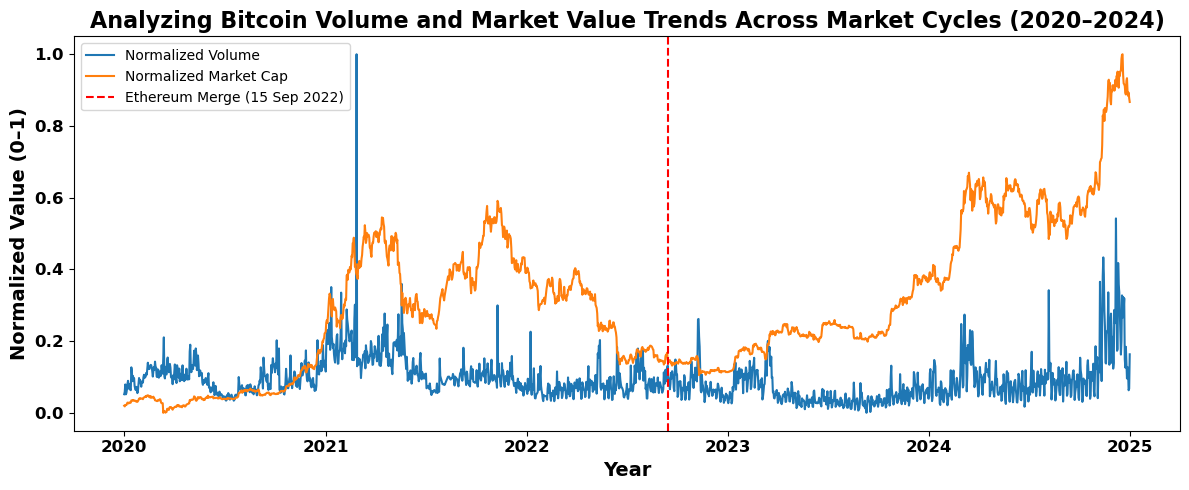

In [53]:
# This block normalizes Bitcoin's daily trading volume to a 0–1 scale.
filtered_data['Btc_Volume_Norm'] = (
    (filtered_data['Btc_Volume'] - filtered_data['Btc_Volume'].min()) /
    (filtered_data['Btc_Volume'].max() - filtered_data['Btc_Volume'].min())
)

# Normalize Bitcoin's market capitalization.
filtered_data['Btc_Marketcap_Norm'] = (
    (filtered_data['Btc_Marketcap'] - filtered_data['Btc_Marketcap'].min()) /
    (filtered_data['Btc_Marketcap'].max() - filtered_data['Btc_Marketcap'].min())
)

# Initialize the line plot.
plt.figure(figsize=(12, 5))

# Plot normalized volume and market cap.
sns.lineplot(data=filtered_data, x='Date', y='Btc_Volume_Norm', label='Normalized Volume')
sns.lineplot(data=filtered_data, x='Date', y='Btc_Marketcap_Norm', label='Normalized Market Cap')

# Add vertical reference for Ethereum Merge.
merge_date = pd.to_datetime('2022-09-15')
plt.axvline(merge_date, color='red', linestyle='--', label='Ethereum Merge (15 Sep 2022)')

# Update title and axis labels with font sizes.
plt.title('Analyzing Bitcoin Volume and Market Value Trends Across Market Cycles (2020–2024)', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Value (0–1)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=14, fontweight='bold')  # ← Changed from 'Date' to 'Year'

# Set tick label font sizes and weights.
plt.xticks(fontsize=12, fontweight='bold')  # ← X-axis tick labels bold
plt.yticks(fontsize=12, fontweight='bold')  # ← Y-axis tick labels bold

# Add legend and adjust layout.
plt.legend()
plt.tight_layout()

# Display the chart.
plt.show()


##### 6.1.5 Correlation between marketcap, liquidity ratio, and volatility

In [54]:
# This block calculates the average yearly market capitalization for Bitcoin and Ethereum.
# It groups the data by year and computes the mean market cap values for each asset.
yearly_marketcap = (
    filtered_data.groupby('Year')
    .agg(
        btc_marketcap=('Btc_Marketcap', 'mean'),
        eth_marketcap=('Eth_Marketcap', 'mean')
    )
    .reset_index()
)

# This step ensures that the 'Year' columns in all relevant DataFrames are in integer format.
# This alignment is necessary for accurate merging across datasets.
yearly_marketcap['Year'] = yearly_marketcap['Year'].astype(int)
liquidity_ratio_yearly['Year'] = liquidity_ratio_yearly['Year'].astype(int)
yearly_volatility['Year'] = yearly_volatility['Year'].astype(int)

# This block merges all yearly datasets—market cap, liquidity ratio, and volatility—into a consolidated summary table.
# The result is a single DataFrame containing aligned metrics for each year.
final_yearly_summary = (
    yearly_marketcap
    .merge(liquidity_ratio_yearly, on='Year')
    .merge(yearly_volatility, on='Year')
)

# This step calculates the correlation matrix for Bitcoin-specific metrics.
# It includes market capitalization, liquidity ratio, and volatility to identify any linear relationships.
btc_corr = final_yearly_summary[
    ['btc_marketcap', 'btc_liquidity_ratio', 'btc_volatility']
].corr()

# This step calculates the same correlation matrix for Ethereum.
# It examines how Ethereum’s market cap relates to its liquidity and volatility over time.
eth_corr = final_yearly_summary[
    ['eth_marketcap', 'eth_liquidity_ratio', 'eth_volatility']
].corr()

# This block prints the correlation results for both Bitcoin and Ethereum.
# The matrices help determine how strongly price stability and liquidity trends align with market capitalization.
print(" Bitcoin Correlation Matrix:")
print(btc_corr)

print("\n Ethereum Correlation Matrix:")
print(eth_corr)


 Bitcoin Correlation Matrix:
                     btc_marketcap  btc_liquidity_ratio  btc_volatility
btc_marketcap                 1.00                -0.74            0.04
btc_liquidity_ratio          -0.74                 1.00            0.81
btc_volatility                0.04                 0.81            1.00

 Ethereum Correlation Matrix:
                     eth_marketcap  eth_liquidity_ratio  eth_volatility
eth_marketcap                 1.00                -0.85            0.25
eth_liquidity_ratio          -0.85                 1.00            0.70
eth_volatility                0.25                 0.70            1.00


##### Answer 1

Ethereum showed relatively higher liquidity and slightly lower volatility post-2022 compared to Bitcoin. This became especially noticeable after Ethereum's transition to PoS (Proof Of Stake).

High liquidity combined with lower volatility can suggest reduced trading risk. Ethereum’s increased liquidity and marginally more stable price behavior post-PoS merge indicates potential growing investor confidence and scalability.

______________________________________________________________________________________________________________________________________________________________________

#### 6.2 Question-2: Has Ethereum’s transition from Proof of Work (PoW) to Proof of Stake (PoS) in 2022 resulted in a tangible reduction in its network difficulty and energy consumption, relative to Bitcoin over the same period?


##### 6.2.1 Ethereum: Energy Consumption & Network Difficulty (2020–2024)'

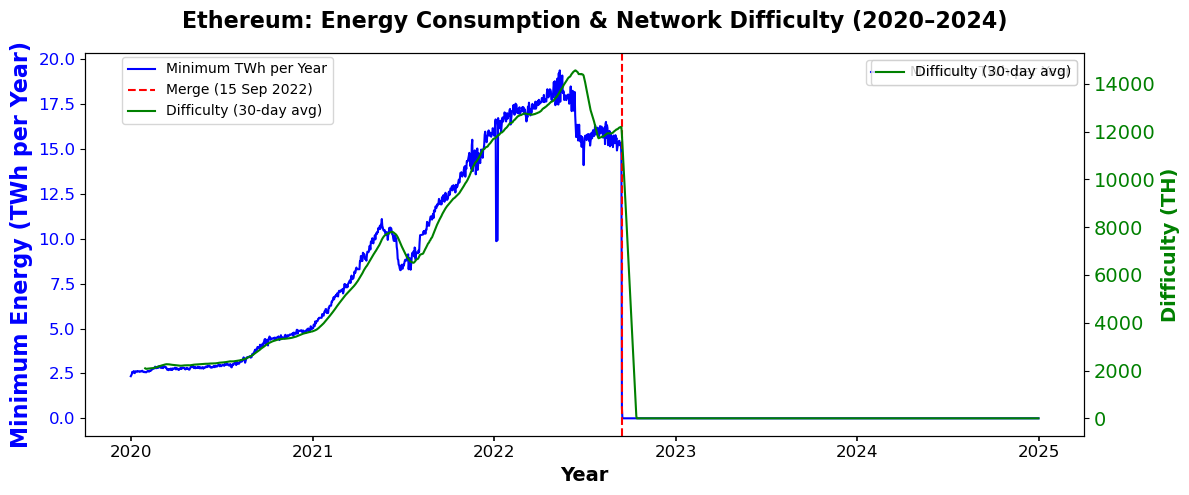

In [55]:
# This step calculates a 30-day rolling average of Ethereum’s network difficulty.
# It smooths out short-term fluctuations and provides a clearer view of long-term trends.
filtered_data['ETH_Difficulty_30d'] = filtered_data['Eth_Average_Difficulty (TH)'].rolling(window=30).mean()

# This block initializes the plot with two y-axes: one for energy consumption and one for difficulty.
# It defines the figure size and creates the first y-axis (on the left).
fig, ax1 = plt.subplots(figsize=(12, 5))

# This section plots Ethereum’s minimum annual energy consumption on the left y-axis using a blue line.
# It also labels the axis and formats the tick labels in the corresponding color.
sns.lineplot(
    data=filtered_data,
    x='Date',
    y='Eth_Minimum TWh per Year',
    ax=ax1,
    color='blue',
    label='Minimum TWh per Year'
)
ax1.set_ylabel('Minimum Energy (TWh per Year)', color='blue', fontsize=16, fontweight='bold')
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')  # <- Updated X-axis label and made it bold
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)  # Set Y-axis tick font size
ax1.tick_params(axis='x', labelsize=12, labelcolor='black', width=1.2)  # Set X-axis tick font size & bold color

# This line marks the date of Ethereum’s transition to Proof of Stake (The Merge) using a vertical dashed line.
# It provides a visual reference point for comparing changes before and after the event.
ax1.axvline(
    pd.to_datetime('2022-09-15'),
    color='red',
    linestyle='--',
    label='Merge (15 Sep 2022)'
)

# This block creates a second y-axis on the right side to display network difficulty.
# It ensures both y-axes share the same x-axis (Date) for alignment.
ax2 = ax1.twinx()

# This section plots the 30-day rolling average of Ethereum’s difficulty using a green line on the right y-axis.
# It also labels the axis and applies consistent tick formatting.
sns.lineplot(
    data=filtered_data,
    x='Date',
    y='ETH_Difficulty_30d',
    ax=ax2,
    color='green',
    label='Difficulty (30-day avg)'
)
ax2.set_ylabel('Difficulty (TH)', color='green', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='green', labelsize=14)  # Set right Y-axis tick font size

# This line sets the overall chart title to describe its content and the date range.
fig.suptitle('Ethereum: Energy Consumption & Network Difficulty (2020–2024)', fontsize=16, fontweight='bold')

# This call adjusts the layout to prevent overlapping text and ensure readability.
fig.tight_layout()

# This block adds a legend to explain the visual elements (lines and reference markers).
# It positions the legend near the top-left corner of the plot for clarity.
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))


##### 6.2.2 Bitcoin: Energy Consumption & Network Difficulty (2020–2024)

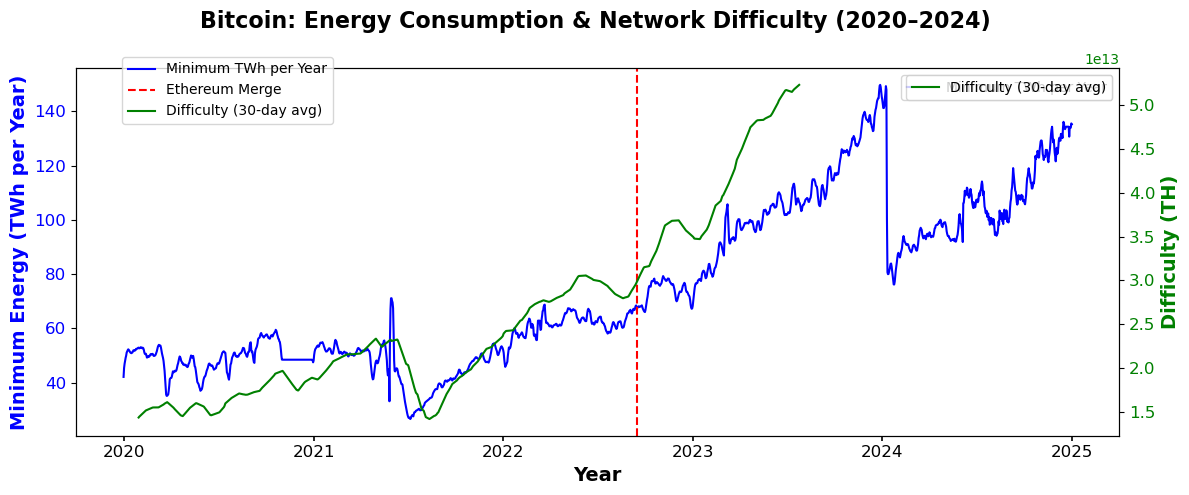

In [56]:
# This step calculates a 30-day rolling average of Bitcoin’s network difficulty.
# It smooths the short-term fluctuations to make long-term difficulty trends easier to interpret.
filtered_data['BTC_Difficulty_30d'] = filtered_data['Btc_Average_Difficulty (TH)'].rolling(window=30).mean()

# This block initializes the plot with dual y-axes.
# The left axis will display energy consumption, and the right axis will show mining difficulty.
fig, ax1 = plt.subplots(figsize=(12, 5))  # Define the figure size as 12 by 5 inches

# This section plots Bitcoin’s minimum annual energy consumption on the left y-axis using a blue line.
# It also sets the corresponding axis label and matches the tick label color to the line.
sns.lineplot(
    data=filtered_data,
    x='Date',
    y='Btc_Minimum TWh per Year',
    ax=ax1,
    color='blue',
    label='Minimum TWh per Year'
)
ax1.set_ylabel('Minimum Energy (TWh per Year)', color='blue', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')  # <- Added X-axis label "Year" in bold
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)  # Set left y-axis tick font size
ax1.tick_params(axis='x', labelsize=12, labelcolor='black', width=1.2)  # Set x-axis tick font bold

# This line draws a vertical reference marker at the date of Ethereum’s Merge.
# It serves as a comparative reference point for both cryptocurrencies.
ax1.axvline(
    pd.to_datetime('2022-09-15'),
    color='red',
    linestyle='--',
    label='Ethereum Merge'
)

# This block creates a secondary y-axis on the right side to plot Bitcoin’s mining difficulty.
# It ensures both axes share the same x-axis, which is the Date.
ax2 = ax1.twinx()

# This section plots the 30-day rolling average of Bitcoin’s network difficulty using a green line.
# It also labels the axis and aligns tick label colors with the data line.
sns.lineplot(
    data=filtered_data,
    x='Date',
    y='BTC_Difficulty_30d',
    ax=ax2,
    color='green',
    label='Difficulty (30-day avg)'
)
ax2.set_ylabel('Difficulty (TH)', color='green', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='green', labelsize=12)  # Set right y-axis tick font size

# This line sets the title of the chart to reflect the data being visualized.
fig.suptitle('Bitcoin: Energy Consumption & Network Difficulty (2020–2024)', fontsize=16, fontweight='bold')

# This call automatically adjusts spacing to ensure all chart elements fit properly.
fig.tight_layout()

# This block adds a legend to identify the lines and the Merge reference.
# It places the legend in the upper-left portion of the plot.
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# This command renders the complete visualization.
plt.show()


##### 6.2.3 Ethereum vs Bitcoin Minimum Energy Consumption(TWh per Year): 2020–2024

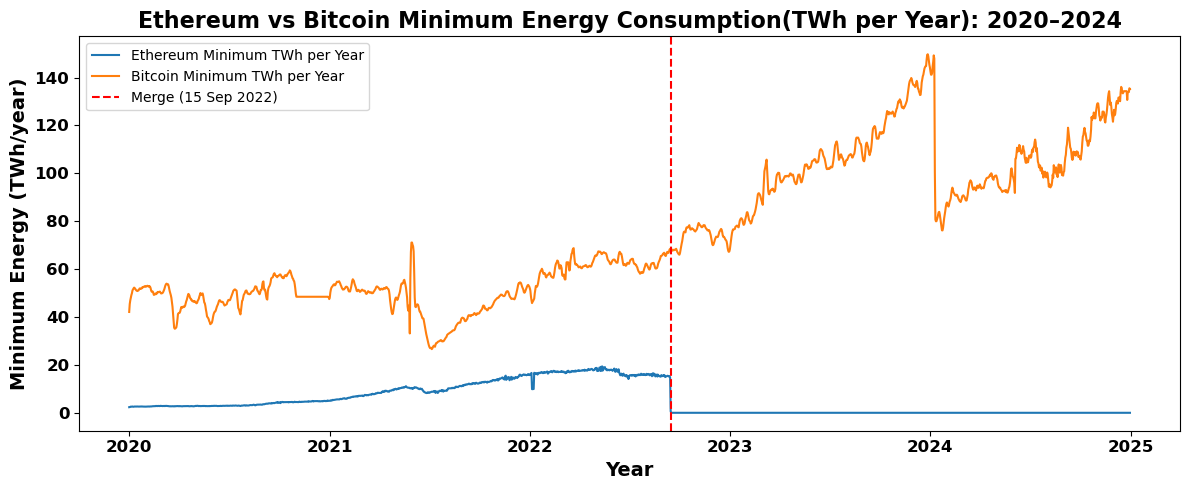

In [57]:
# This block defines the date when Ethereum transitioned from Proof of Work (PoW) to Proof of Stake (PoS).
# It then creates a new column that flags all dates on or after the Merge as 'Post_Merge = True'.
merge_date = pd.to_datetime('2022-09-15')  # Define the Merge date
filtered_data['Post_Merge'] = filtered_data['Date'] >= merge_date  # Create boolean flag for post-Merge period

# This block initializes a new figure to compare energy consumption between Ethereum and Bitcoin.
# It sets the figure size to 12 inches wide and 5 inches tall for clarity.
plt.figure(figsize=(12, 5))

# This line plots Ethereum’s minimum annual energy consumption over time using a default line style.
# It helps visualize how Ethereum’s energy usage changed during the 2020–2024 period.
sns.lineplot(
    data=filtered_data,
    x='Date',
    y='Eth_Minimum TWh per Year',
    label='Ethereum Minimum TWh per Year'
)

# This line plots Bitcoin’s minimum annual energy consumption over time on the same axes.
# It allows direct visual comparison with Ethereum.
sns.lineplot(
    data=filtered_data,
    x='Date',
    y='Btc_Minimum TWh per Year',
    label='Bitcoin Minimum TWh per Year'
)

# This line adds a vertical marker to indicate the date of Ethereum’s Merge.
# It visually separates the pre- and post-Merge periods on the timeline.
plt.axvline(
    merge_date,
    color='red',
    linestyle='--',
    label='Merge (15 Sep 2022)'
)

# This block sets the chart’s title and the y-axis label to provide context.
# It also adds a legend to identify the plotted lines and the Merge event.
plt.title('Ethereum vs Bitcoin Minimum Energy Consumption(TWh per Year): 2020–2024', fontsize=16, fontweight='bold')
plt.ylabel('Minimum Energy (TWh/year)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=14, fontweight='bold')  # <- X-axis label changed and bold
plt.xticks(fontsize=12, fontweight='bold')  # <- X-axis ticks bold
plt.yticks(fontsize=12, fontweight='bold')  # <- Y-axis ticks bold

plt.legend()

# This call adjusts spacing to ensure that titles, labels, and legends are displayed properly.
plt.tight_layout()

# This command renders and displays the final line chart.
plt.show()


##### 6.2.4 Ethereum Pre-Merge: Difficulty vs Energy Consumption

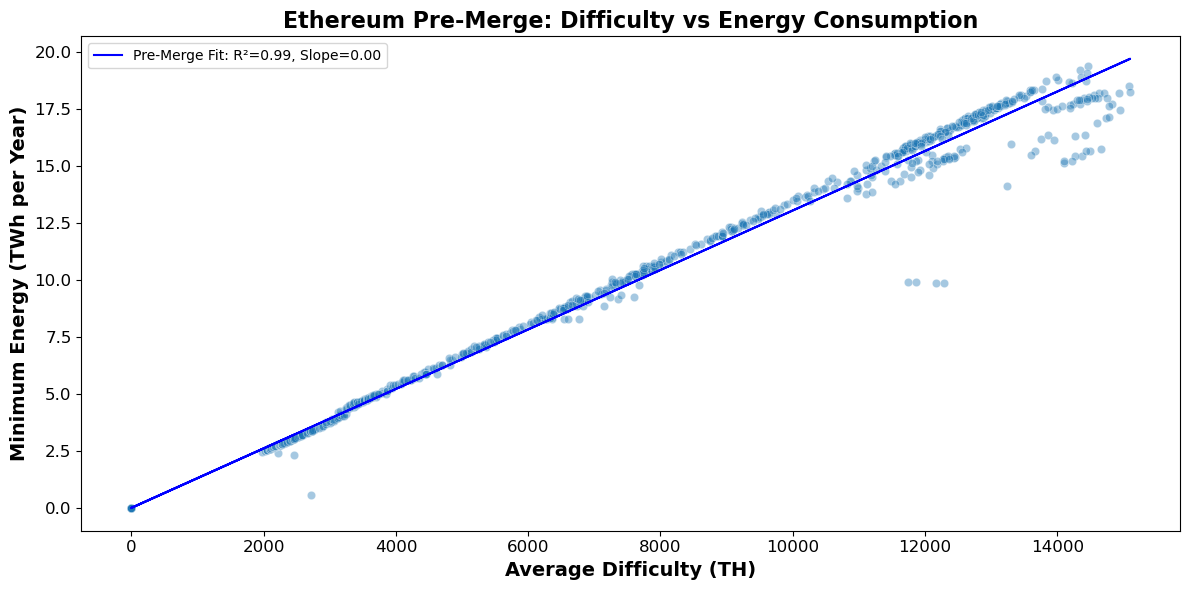

In [58]:
# This block prepares the input (X) and output (y) variables for regression analysis.
# It extracts Ethereum’s average difficulty as the independent variable,
# and minimum annual energy consumption as the dependent variable.
X_pre = filtered_data[['Eth_Average_Difficulty (TH)']].values
y_pre = filtered_data['Eth_Minimum TWh per Year'].values

# This block fits a linear regression model to examine the relationship between difficulty and energy use.
# It also calculates the R-squared value and the slope of the fitted regression line.
model_pre = LinearRegression().fit(X_pre, y_pre)
r2_pre = model_pre.score(X_pre, y_pre)         # Measures how well the model explains the variance in energy
slope_pre = model_pre.coef_[0]                 # Represents the rate of change in energy with respect to difficulty

# This block creates a scatter plot of Ethereum’s difficulty versus energy consumption,
# and overlays the fitted regression line to visualize the trend.
plt.figure(figsize=(12, 6))  # Set the figure size to ensure clarity

# Plot the raw data points as a scatter plot with reduced opacity
sns.scatterplot(
    x='Eth_Average_Difficulty (TH)',
    y='Eth_Minimum TWh per Year',
    data=filtered_data,
    alpha=0.4
)

# Plot the regression line and annotate it with the R² and slope values
plt.plot(
    filtered_data['Eth_Average_Difficulty (TH)'],
    model_pre.predict(X_pre),
    color='blue',
    label=f'Pre-Merge Fit: R²={r2_pre:.2f}, Slope={slope_pre:.2f}'
)

# Set the title and axis labels to describe the chart’s content
plt.title('Ethereum Pre-Merge: Difficulty vs Energy Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Average Difficulty (TH)', fontsize=14,fontweight='bold')
plt.ylabel('Minimum Energy (TWh per Year)', fontsize=14, fontweight='bold')  # ← Updated

# Display the legend to explain the regression line
plt.legend()

# Adjust layout for better spacing and clarity
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Display the final plot
plt.show()


##### 6.2.5 Bitcoin: Difficulty vs Energy Consumption

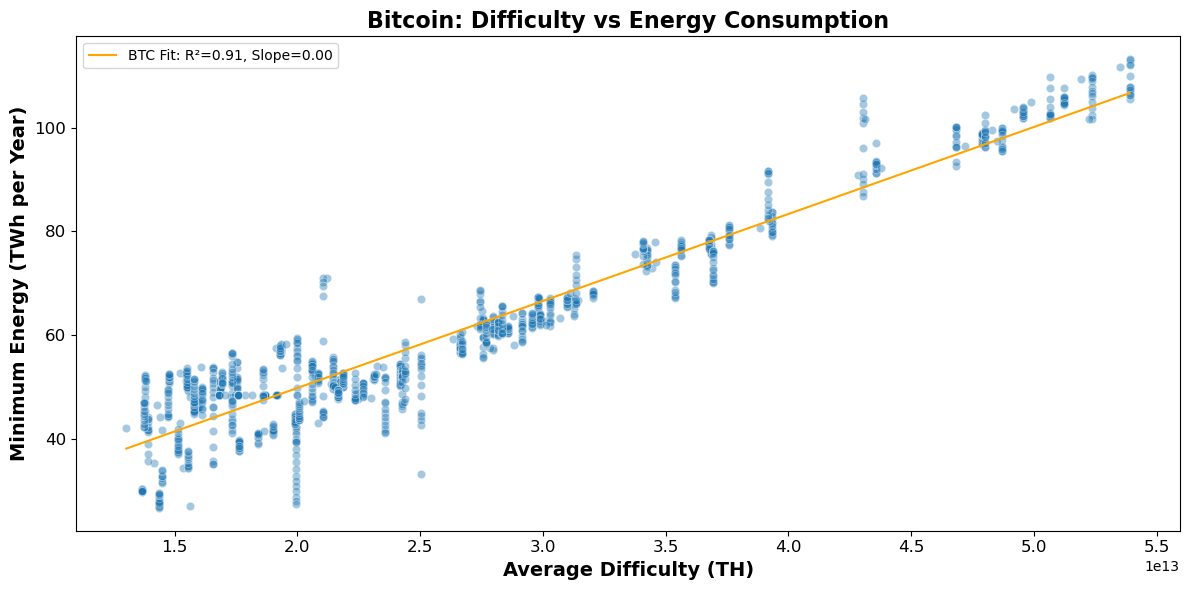

In [59]:
# This step removes rows that have missing values in either the difficulty or energy columns for Bitcoin.
# It ensures that the regression model only uses complete and valid data points.
btc_clean = filtered_data.dropna(subset=['Btc_Average_Difficulty (TH)', 'Btc_Minimum TWh per Year'])

# This step defines the independent (X) and dependent (y) variables for the regression model.
# It uses Bitcoin’s average difficulty as the predictor and energy consumption as the outcome.
X_btc = btc_clean[['Btc_Average_Difficulty (TH)']].values  # Reshape to (n, 1) for sklearn
y_btc = btc_clean['Btc_Minimum TWh per Year'].values     # Extract the target variable as a flat array

# This block fits a linear regression model using the cleaned Bitcoin data.
# It also calculates the R-squared value and slope of the fitted regression line.
btc_model = LinearRegression().fit(X_btc, y_btc)
r2_btc = btc_model.score(X_btc, y_btc)          # Indicates how well difficulty explains energy use
slope_btc = btc_model.coef_[0]                  # Represents the change in energy per unit increase in difficulty

# This block visualizes the relationship between Bitcoin difficulty and energy consumption.
# It overlays the regression line on top of the scatter plot for interpretation.
plt.figure(figsize=(12, 6))  # Define the figure size for clarity

# Plot the raw data points as a scatter plot with partial transparency
sns.scatterplot(
    x='Btc_Average_Difficulty (TH)',
    y='Btc_Minimum TWh per Year',
    data=btc_clean,
    alpha=0.4
)

# Plot the regression line and include its R² and slope in the legend
plt.plot(
    btc_clean['Btc_Average_Difficulty (TH)'],
    btc_model.predict(X_btc),
    color='orange',
    label=f'BTC Fit: R²={r2_btc:.2f}, Slope={slope_btc:.2f}'
)

# Add title and axis labels to describe the chart content
plt.title('Bitcoin: Difficulty vs Energy Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Average Difficulty (TH)', fontsize=14,fontweight='bold')
plt.ylabel('Minimum Energy (TWh per Year)', fontsize=14,fontweight='bold')

# Add a legend to identify the regression line
plt.legend()

# Automatically adjust the layout to avoid overlapping elements
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Display the plot
plt.show()


##### Answer 2

Ethereum’s network difficulty flatlined (near-zero) after the PoS (Proof Of Stake) transition, and energy consumption dropped over 99.9% post-merge. Bitcoin, by contrast, continued to show rising difficulty and consistently high energy use. 

Ethereum’s environmental upgrade is clearly visible in the data. This has implications for (Environmental Social Governance) ESG-minded portfolios and may support regulatory or investment decisions aimed at prioritizing sustainable blockchain technologies and reducing the carbon footprint of digital assets in institutional portfolios.

______________________________________________________________________________________________________________________________________________________________________

#### 6.3 Question-3:  During periods of extreme market stress (2022 crypto crash), which asset, Bitcoin or Ethereum, exhibited stronger investor confidence based on sustained trading volume and recovery patterns?

##### 6.3.1 Filtering the time period of crypto crash

In [60]:
#  Filter to crash window and recovery period (May to Aug 2022)
start = "2022-05-01"
end = "2022-08-31"
btc_crash = filtered_data[(filtered_data['Date'] >= start) & (filtered_data['Date'] <= end)]
eth_crash = filtered_data[(filtered_data['Date'] >= start) & (filtered_data['Date'] <= end)]


##### 6.3.2 Bitcoin and Ethereum Trading Volume Recovery After the 2022 Market Crash 

Bitcoin Volume % Drop: 38.84%
Bitcoin Volume % Recovery: 200.64%
Ethereum Volume % Drop: 73.06%
Ethereum Volume % Recovery: 33.78%


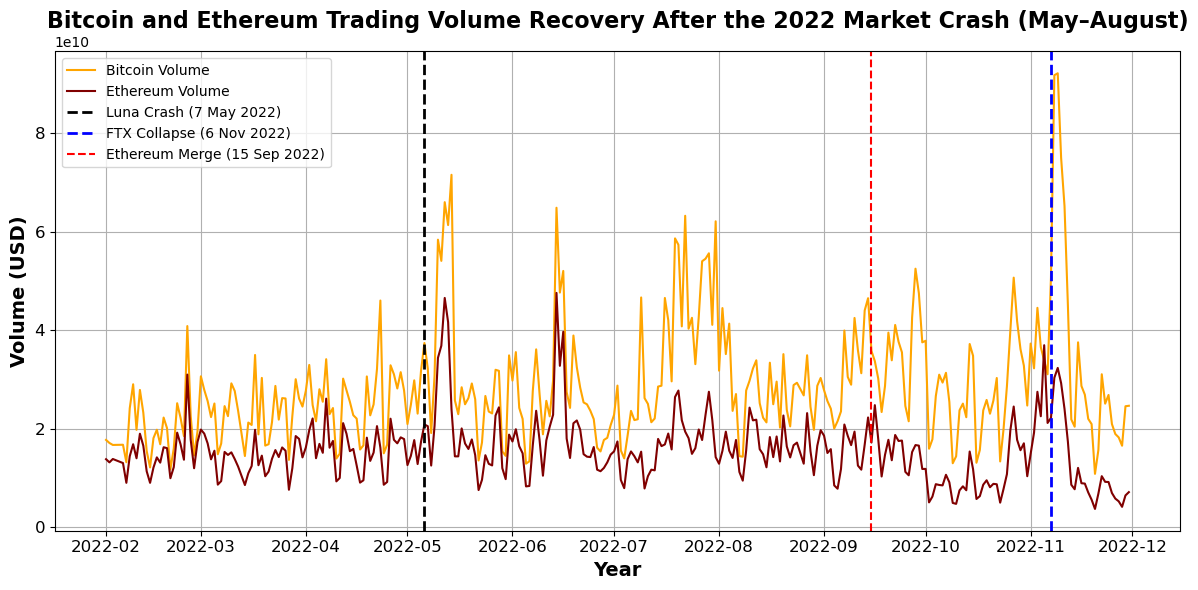

In [61]:
#  Filter to crash window and recovery period (May to Aug 2022)
start = "2022-02-01"
end = "2022-11-30"
btc_crash = filtered_data[(filtered_data['Date'] >= start) & (filtered_data['Date'] <= end)]
eth_crash = filtered_data[(filtered_data['Date'] >= start) & (filtered_data['Date'] <= end)]

# Calculate % drop and recovery in Volume for Bitcoin
btc_volume_drop = btc_crash['Btc_Volume'].iloc[0] - btc_crash['Btc_Volume'].min()
btc_volume_recovery = btc_crash['Btc_Volume'].iloc[-1] - btc_crash['Btc_Volume'].min()

# Calculate % drop and recovery in Volume for Ethereum
eth_volume_drop = eth_crash['Eth_Volume'].iloc[0] - eth_crash['Eth_Volume'].min()
eth_volume_recovery = eth_crash['Eth_Volume'].iloc[-1] - eth_crash['Eth_Volume'].min()

# Print the percentage drop and recovery
print(f"Bitcoin Volume % Drop: {(btc_volume_drop / btc_crash['Btc_Volume'].iloc[0]) * 100:.2f}%")
print(f"Bitcoin Volume % Recovery: {(btc_volume_recovery / btc_volume_drop) * 100:.2f}%")
print(f"Ethereum Volume % Drop: {(eth_volume_drop / eth_crash['Eth_Volume'].iloc[0]) * 100:.2f}%")
print(f"Ethereum Volume % Recovery: {(eth_volume_recovery / eth_volume_drop) * 100:.2f}%")

# Define the crash window dates
crash_start = pd.to_datetime("2022-05-06")
crash_end = pd.to_datetime("2022-11-07")
merge_date = pd.to_datetime('2022-09-15')



# Plot volume data
plt.figure(figsize=(12, 6))
plt.plot(btc_crash['Date'], btc_crash['Btc_Volume'], label='Bitcoin Volume', color='orange')
plt.plot(eth_crash['Date'], eth_crash['Eth_Volume'], label='Ethereum Volume', color='maroon')


# Add vertical red dotted lines
plt.axvline(crash_start, color='black', linestyle='--', linewidth=2, label='Luna Crash (7 May 2022)')
plt.axvline(crash_end, color='blue', linestyle='--', linewidth=2, label='FTX Collapse (6 Nov 2022)')
plt.axvline(merge_date, color='red', linestyle='--', label='Ethereum Merge (15 Sep 2022)')

# Updated title and fonts
plt.title('Bitcoin and Ethereum Trading Volume Recovery After the 2022 Market Crash (May–August)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Volume (USD)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Answer 3

During the 2022 crypto crash, Bitcoin exhibited stronger investor confidence compared to Ethereum, based on two key indicators: sustained trading volume and market cap recovery.

Trading Volume: While both assets saw a decline in volume during the crash, Bitcoin maintained relatively higher and more consistent daily trading volumes, suggesting continued participation and liquidity in the market.

Recovery Patterns: Bitcoin’s market capitalization showed a quicker and more stable rebound post-crash, particularly after the FTX collapse. Ethereum’s recovery was slower and more volatile, likely influenced by uncertainty around its recent transition to Proof of Stake.


______________________________________________________________________________________________________________________________________________________________________

#### 6.4 Question-4.How did Bitcoin’s network difficulty trend evolve from mid-2023 to 2025, and what implications does this have for mining sustainability and energy consumption beyond the available dataset?

Limitations of our dataset 

Our combined dataset only covered network difficulty values up to mid-2023 creating a critical blind spot in our analysis.

This limitation restricted our ability to evaluate recent shifts in mining intensity, emerging energy demands, and the evolving stability of the Bitcoin network between 2023 and 2025.

Without up-to-date data, any conclusions about long-term sustainability or market readiness risk being incomplete or outdated.

##### 6.4.1 Web Scrapping

In [62]:
# Get the full dataset
url = "https://api.blockchain.info/charts/difficulty?timespan=3years&sampled=true&metadata=false&daysAverageString=1d&cors=true&format=json" 
res = requests.get(url)
data = res.json()

# Convert JSON response to DataFrame
scrape_bitcoin_difficulty = pd.DataFrame(data['values'])

# Convert timestamp to readable date format
scrape_bitcoin_difficulty['Date'] = pd.to_datetime(scrape_bitcoin_difficulty['x'], unit='s')

# Rename 'y' to 'Difficulty'
scrape_bitcoin_difficulty['Difficulty'] = scrape_bitcoin_difficulty['y']

# Keep only necessary columns
scrape_bitcoin_difficulty = scrape_bitcoin_difficulty[['Date', 'Difficulty']]

# Display preview
print(scrape_bitcoin_difficulty.head())

# Optional: Save to CSV
scrape_bitcoin_difficulty.to_csv("bitcoin_difficulty_history.csv", index=False)

# Output final DataFrame
explore_dataset(scrape_bitcoin_difficulty,"scrape_bitcoin_difficulty")

        Date            Difficulty
0 2022-06-06 29,897,409,688,834.00
1 2022-06-07 29,897,409,688,834.00
2 2022-06-08 30,107,694,713,067.66
3 2022-06-09 30,283,293,547,737.00
4 2022-06-10 30,283,293,547,737.00

 Dataset: scrape_bitcoin_difficulty
------------------------------------------------------------
Shape (Rows, Columns): (1094, 2)
Column Names: ['Date', 'Difficulty']
Data Types:
Date          datetime64[ns]
Difficulty           float64
dtype: object
Missing Values:
Date          0
Difficulty    0
dtype: int64
First 5 Rows:
        Date            Difficulty
0 2022-06-06 29,897,409,688,834.00
1 2022-06-07 29,897,409,688,834.00
2 2022-06-08 30,107,694,713,067.66
3 2022-06-09 30,283,293,547,737.00
4 2022-06-10 30,283,293,547,737.00
Last 5 Rows:
           Date             Difficulty
1089 2025-05-30 121,658,450,774,824.48
1090 2025-05-31 126,982,285,146,988.45
1091 2025-06-01 126,982,285,146,988.55
1092 2025-06-02 126,982,285,146,988.55
1093 2025-06-03 126,982,285,146,988.50
Statis

##### 6.4.2 Merging 

In [63]:
# Step 1: Merge the scraped difficulty into filtered_data on 'Date'
merged_data = filtered_data.merge(
    scrape_bitcoin_difficulty,
    on='Date',
    how='left',
    suffixes=('', '_scraped')  # to avoid overwriting original columns
)

# Step 2: Update only if original value is NaN or 0
condition = merged_data['Btc_Average_Difficulty (TH)'].isna() | (merged_data['Btc_Average_Difficulty (TH)'] == 0)
merged_data.loc[condition, 'Btc_Average_Difficulty (TH)'] = merged_data.loc[condition, 'Difficulty']

# Step 3: Save the cleaned dataset back
merged_data['Btc_Average_Difficulty (TH)']


0       13,031,658,000,898.63
1       13,798,783,827,516.42
2       13,798,783,827,516.42
3       13,798,783,827,516.42
4       13,798,783,827,516.42
                ...          
1807   108,522,647,629,298.00
1808   108,522,647,629,298.00
1809   108,610,329,323,384.50
1810   109,782,075,598,904.53
1811   109,782,075,598,904.66
Name: Btc_Average_Difficulty (TH), Length: 1812, dtype: float64

##### 6.4.3 Complete linear regression of Bitcoin Difficulty vs Energy Consumption

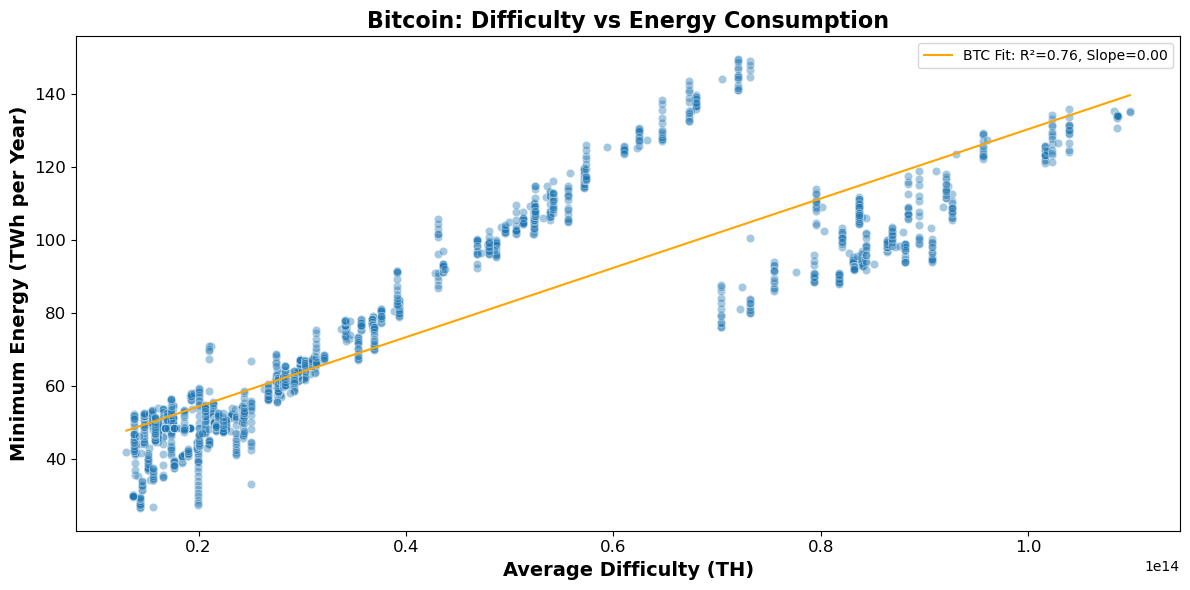

In [64]:
# This step removes rows that have missing values in either the difficulty or energy columns for Bitcoin.
# It ensures that the regression model only uses complete and valid data points.
btc_clean = merged_data.dropna(subset=['Btc_Average_Difficulty (TH)', 'Btc_Minimum TWh per Year'])

# This step defines the independent (X) and dependent (y) variables for the regression model.
# It uses Bitcoin’s average difficulty as the predictor and energy consumption as the outcome.
X_btc = btc_clean[['Btc_Average_Difficulty (TH)']].values  # Reshape to (n, 1) for sklearn
y_btc = btc_clean['Btc_Minimum TWh per Year'].values     # Extract the target variable as a flat array

# This block fits a linear regression model using the cleaned Bitcoin data.
# It also calculates the R-squared value and slope of the fitted regression line.
btc_model = LinearRegression().fit(X_btc, y_btc)
r2_btc = btc_model.score(X_btc, y_btc)          # Indicates how well difficulty explains energy use
slope_btc = btc_model.coef_[0]                  # Represents the change in energy per unit increase in difficulty

# This block visualizes the relationship between Bitcoin difficulty and energy consumption.
# It overlays the regression line on top of the scatter plot for interpretation.
plt.figure(figsize=(12, 6))  # Define the figure size for clarity

# Plot the raw data points as a scatter plot with partial transparency
sns.scatterplot(
    x='Btc_Average_Difficulty (TH)',
    y='Btc_Minimum TWh per Year',
    data=btc_clean,
    alpha=0.4
)

# Plot the regression line and include its R² and slope in the legend
plt.plot(
    btc_clean['Btc_Average_Difficulty (TH)'],
    btc_model.predict(X_btc),
    color='orange',
    label=f'BTC Fit: R²={r2_btc:.2f}, Slope={slope_btc:.2f}'
)

# Add title and axis labels to describe the chart content
plt.title('Bitcoin: Difficulty vs Energy Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Average Difficulty (TH)', fontsize=14,fontweight='bold')
plt.ylabel('Minimum Energy (TWh per Year)', fontsize=14,fontweight='bold')

# Add a legend to identify the regression line
plt.legend()

# Automatically adjust the layout to avoid overlapping elements
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Display the plot
plt.show()


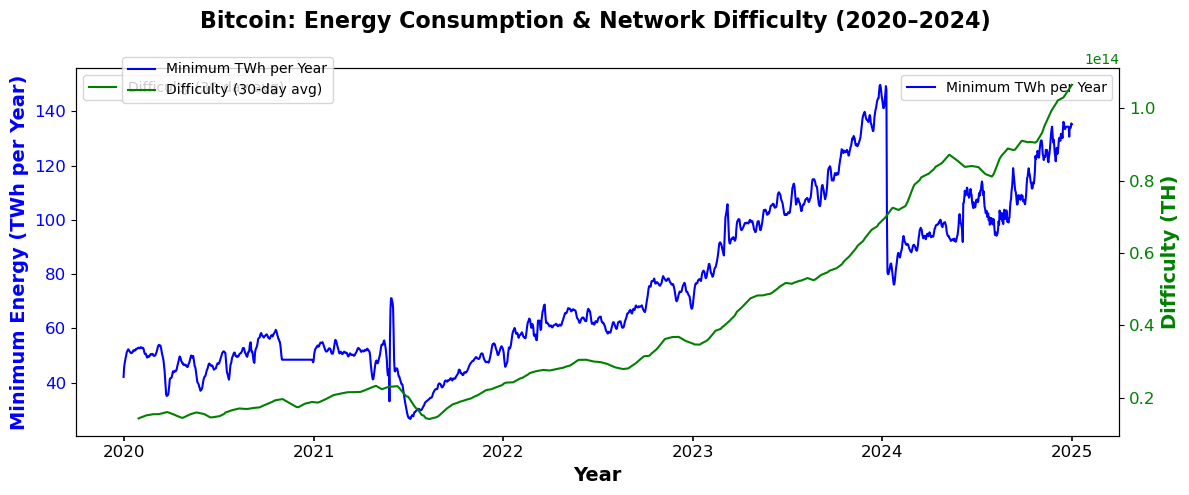

In [65]:
# This step calculates a 30-day rolling average of Bitcoin’s network difficulty.
# It smooths the short-term fluctuations to make long-term difficulty trends easier to interpret.
merged_data['BTC_Difficulty_30d'] = merged_data['Btc_Average_Difficulty (TH)'].rolling(window=30).mean()

# This block initializes the plot with dual y-axes.
# The left axis will display energy consumption, and the right axis will show mining difficulty.
fig, ax1 = plt.subplots(figsize=(12, 5))  # Define the figure size as 12 by 5 inches

# This section plots Bitcoin’s minimum annual energy consumption on the left y-axis using a blue line.
# It also sets the corresponding axis label and matches the tick label color to the line.
sns.lineplot(
    data=merged_data,
    x='Date',
    y='Btc_Minimum TWh per Year',
    ax=ax1,
    color='blue',
    label='Minimum TWh per Year'
)
ax1.set_ylabel('Minimum Energy (TWh per Year)', color='blue', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')  # <- Added X-axis label "Year" in bold
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)  # Set left y-axis tick font size
ax1.tick_params(axis='x', labelsize=12, labelcolor='black', width=1.2)  # Set x-axis tick font bold

# This block creates a secondary y-axis on the right side to plot Bitcoin’s mining difficulty.
# It ensures both axes share the same x-axis, which is the Date.
ax2 = ax1.twinx()

# This section plots the 30-day rolling average of Bitcoin’s network difficulty using a green line.
# It also labels the axis and aligns tick label colors with the data line.
sns.lineplot(
    data=merged_data,
    x='Date',
    y='BTC_Difficulty_30d',
    ax=ax2,
    color='green',
    label='Difficulty (30-day avg)'
)
ax2.set_ylabel('Difficulty (TH)', color='green', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='green', labelsize=12)  # Set right y-axis tick font size

# This line sets the title of the chart to reflect the data being visualized.
fig.suptitle('Bitcoin: Energy Consumption & Network Difficulty (2020–2024)', fontsize=16, fontweight='bold')

# This call automatically adjusts spacing to ensure all chart elements fit properly.
fig.tight_layout()

# This block adds a legend to identify the lines and the Merge reference.
# It places the legend in the upper-left portion of the plot.
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# This command renders the complete visualization.
plt.show()


## Web scrapping 

Steps Taken: 
Accessed Blockchain API
 Queried Bitcoin difficulty data for the last 3 years using:
 https://www.blockchain.com/charts/difficulty

Fetched & Parsed Data
 Used Python’s requests library to extract JSON-formatted data.


Processed into Usable Format
 Converted JSON into a pandas DataFrame, transformed Unix timestamps to readable dates, and renamed key columns for clarity.


Cleaned & Filtered Columns
 Retained only Date and Difficulty fields for focused analysis.


Extended the Dataset
 Merged the scraped data with our filtered dataset to create a continuous view from 2020 through 2024.


Used in Final Visualization
 Generated updated plots incorporating difficulty trends through 2024 to answer the limitation

##### **Solution for the limitation**

Using web-scraped data from **[Blockchain.com](https://www.blockchain.com/charts/difficulty)**, we extended our dataset to include Bitcoin's network difficulty from mid-2023 to 2025. The data reveals a continued upward trend in difficulty, indicating that mining has become increasingly competitive and energy-intensive.

As difficulty rises, more computational power and thus more electricity is required to solve blocks, which directly increases energy consumption. This sustained escalation reinforces the environmental concerns associated with Bitcoin’s Proof of Work (PoW) model.

These findings strengthen the case for (Environmental Social Governance) ESG-conscious investors and regulators to scrutinize PoW assets and potentially favor energy-efficient alternatives like Ethereum post-Merge.


______________________________________________________________________________________________________________________________________________________________________

### **Conclusion**

This project offered a deep comparative lens into Bitcoin and Ethereum's evolving dynamics in terms of performance, sustainability, resilience, and investor perception. By integrating multiple datasets across price, volume, network difficulty, and energy consumption, we uncovered critical patterns that help explain how each asset responds to market pressure and innovation.

Ethereum's transition to Proof of Stake has not only slashed its energy use by over 99.9% but also reshaped its market narrative, highlighting the growing role of  (Environmental Social Governance) ESG-conscious investing in crypto. Meanwhile, Bitcoin's continued reliance on Proof of Work raises pressing environmental questions, especially as its network difficulty and power demands escalate.

Through web scraping, we extended our analysis into 2025, revealing that Bitcoin's energy trajectory remains upward, underscoring the need for policy, infrastructure, and investor awareness to evolve with it.

In the end, our findings suggest that crypto's future will not be defined by technology alone but by the values of the investors who fuel it, those who demand not just profit but accountability, sustainability, and long-term resilience.


______________________________________________________________________________________________________________________________________________________________________

### **References**

Bitcoin Blockchain Historical Data | Spreadsheet Download | Gigasheet. (2025). Gigasheet.com. https://gigasheet.com/sample-data/bitcoin-blockchain-historical-data

Blockchain.com. (2020). Difficulty. https://www.blockchain.com/charts/difficulty

CoinGecko. (2025). Bitcoin (BTC) price, marketcap, chart, and info. https://www.coingecko.com/en/coins/bitcoin

Coingecko. (n.d.). Ethereum (ETH) price, marketcap, chart, and info. https://www.coingecko.com/en/coins/ethereum

Digiconomist. (2021). Ethereum Energy Consumption Index. https://digiconomist.net/ethereum-energy-consumption

Digiconomist. (2024). Bitcoin Energy Consumption Index - Digiconomist. https://digiconomist.net/bitcoin-energy-consumption

Etherscan.io. (2015). Ethereum Network Difficulty Chart | Etherscan. https://etherscan.io/chart/difficulty

Investing.com. (2024). Bitcoin Historical Data. https://www.investing.com/crypto/bitcoin/historical-data

Investing.com. (n.d.). Ethereum Historical Data. https://www.investing.com/crypto/ethereum/historical-data

Kumar, S. (n.d.). Cryptocurrency Historical Prices. Kaggle. https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory

OpenAI. (2023). ChatGPT (Mar 23 version) [Large language model]. https://chat.openai.com/
